In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import os
import pandas as pd
import gc
from datetime import timedelta

In [2]:
years = [2008, 2009, 2010, 2011, 2012]
hrdps_files_by_year = {}
for year in years:
    files = sorted(glob.glob(f"/results/forcing/atmospheric/GEM2.5/gemlam/"f"gemlam_y{year}m??d??.nc"))
    hrdps_files_by_year[year] = files
    print(year, ":", files[0], files[-1])

2008 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2008m01d01.nc /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2008m12d31.nc
2009 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2009m01d01.nc /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2009m12d31.nc
2010 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2010m01d01.nc /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2010m12d31.nc
2011 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2011m01d01.nc /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2011m12d31.nc
2012 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2012m01d01.nc /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2012m12d31.nc


In [3]:
# Loading datasets

weights_pre_file = "/home/sallen/MEOPAR/grid/weights-gem2.5-gemlam_201702_pre22sep11.nc"
weights_post_file = "/home/sallen/MEOPAR/grid/weights-gem2.5-gemlam_201702_22sep11onward.nc"
mesh_mask_file = "/ocean/dtaneja/MOAD/analysis-dishika/grid/mesh_mask202108.nc"

ds_weights_pre = xr.open_dataset(weights_pre_file).load()
ds_weights_post = xr.open_dataset(weights_post_file).load()

with xr.open_dataset(mesh_mask_file) as ds_mesh:
    nemo_lat = ds_mesh["nav_lat"].load()
    nemo_lon = ds_mesh["nav_lon"].load()

In [4]:
transition_time = pd.Timestamp("2011-09-22 00:00:00")
wind_component_names = ["u_wind","v_wind"]

def interpolate_wind_component_with_weights(wind_component,ds_weights,variable_name,):
    wind_component = wind_component.transpose("time_counter","y","x",)
    n_time = wind_component.sizes["time_counter"]
    source_shape = (wind_component.sizes["y"],wind_component.sizes["x"],)
    n_source_cells = (source_shape[0] * source_shape[1])
    source_values = (wind_component.values.reshape(n_time,n_source_cells,).astype(np.float32))
    target_shape = ds_weights["src01"].shape
    interpolated = np.zeros((n_time,target_shape[0],target_shape[1],),dtype=np.float32,)

    for n in range(1, 5):
        source_index = (ds_weights[f"src{n:02d}"].values.astype(np.int64)- 1 )
        weight = (ds_weights[f"wgt{n:02d}"].values.astype(np.float32))
        interpolated += (source_values[:, source_index]* weight[None, :, :])

    wind_nemo = xr.DataArray(
        interpolated,dims=("time_counter","y","x",),
        coords={"time_counter":wind_component["time_counter"],"nav_lat": (("y", "x"),nemo_lat.values,),"nav_lon": (("y", "x"),nemo_lon.values,),},
        name=variable_name,)

    wind_nemo.attrs = (wind_component.attrs.copy())
    wind_nemo.attrs["grid"] = ("SalishSeaCast NEMO grid")
    wind_nemo.attrs["interpolation"] = ("Four-source weighted HRDPS-to-NEMO interpolation")
    return wind_nemo

In [5]:
def extract_and_interpolate_hourly_wind(file):
    with xr.open_dataset(file) as ds:
        wind = (ds[wind_component_names].sortby("time_counter"))
        time_index = wind.get_index("time_counter")
        if time_index.has_duplicates:
            unique_mask = (~time_index.duplicated())
            wind = wind.isel(time_counter=unique_mask)
        wind = wind.load()
    times = pd.to_datetime(wind["time_counter"].values)
    before_transition = (times < transition_time)
    after_transition = (times >= transition_time)
    interpolated_pieces = []
    if before_transition.any():
        wind_pre = wind.isel(time_counter=np.where(before_transition)[0])
        pre_dataset = xr.Dataset({
                variable_name:
                    interpolate_wind_component_with_weights(
                        wind_pre[variable_name],
                        ds_weights_pre,
                        variable_name,
                    )
                for variable_name
                in wind_component_names})
        interpolated_pieces.append(pre_dataset)

    if after_transition.any():
        wind_post = wind.isel(time_counter=np.where(after_transition)[0])
        post_dataset = xr.Dataset({
                variable_name:
                    interpolate_wind_component_with_weights(
                        wind_post[variable_name],
                        ds_weights_post,
                        variable_name,
                    )
                for variable_name
                in wind_component_names})
        interpolated_pieces.append(post_dataset)

    wind_nemo = xr.concat(interpolated_pieces,dim="time_counter",).sortby("time_counter")
    return wind_nemo

In [6]:
with xr.open_dataset(mesh_mask_file) as ds_mesh:
    water_mask = (ds_mesh["tmask"].isel(t=0, z=0).load().values.astype(bool))
    nemo_lat_2d = (ds_mesh["nav_lat"].load().values)
    nemo_lon_2d = (ds_mesh["nav_lon"].load().values)

nemo_j, nemo_i = np.where(water_mask)
water_flat_indices = np.flatnonzero(water_mask.reshape(-1))
nemo_water_lat = (nemo_lat_2d[water_mask])
nemo_water_lon = (nemo_lon_2d[water_mask])
n_water = len(water_flat_indices)
print("NEMO grid shape:",water_mask.shape)
print("Number of surface water cells:",n_water)

NEMO grid shape: (898, 398)
Number of surface water cells: 81383


In [7]:
def process_daily_file_to_3h_water(file):
    wind_nemo_hourly = (extract_and_interpolate_hourly_wind(file))
    n_time = wind_nemo_hourly.sizes[ "time_counter"]
    water_components = {}
    for variable_name in wind_component_names:
        component_values = (wind_nemo_hourly[variable_name].values.reshape(n_time, -1)[:, water_flat_indices].astype(np.float32))
        component_water_hourly = xr.DataArray(component_values,dims=("time_counter","water_cell",),
            coords={"time_counter":wind_nemo_hourly["time_counter"].values,"water_cell":np.arange(n_water,dtype=np.int32,),},
            name=variable_name,
            attrs=(wind_nemo_hourly[variable_name].attrs),)
        water_components[variable_name] = (component_water_hourly)

    wind_water_hourly = xr.Dataset(water_components)

    wind_water_3h = (wind_water_hourly.resample(time_counter="3h",label="left",closed="left",origin="start_day",).mean())
    return wind_water_3h.load()

In [8]:
test_file = (hrdps_files_by_year[2008][0])
test_3h = (process_daily_file_to_3h_water(test_file))
print(test_3h)
print("U shape:",test_3h["u_wind"].shape,)
print("V shape:",test_3h["v_wind"].shape,)
print("Times:",test_3h.time_counter.values,)

<xarray.Dataset> Size: 6MB
Dimensions:       (time_counter: 8, water_cell: 81383)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 64B 2008-01-01 ... 2008-01-01...
  * water_cell    (water_cell) int32 326kB 0 1 2 3 4 ... 81379 81380 81381 81382
Data variables:
    u_wind        (time_counter, water_cell) float32 3MB -2.045 ... 0.4804
    v_wind        (time_counter, water_cell) float32 3MB -1.719 ... -0.3571
U shape: (8, 81383)
V shape: (8, 81383)
Times: ['2008-01-01T00:00:00.000000000' '2008-01-01T03:00:00.000000000'
 '2008-01-01T06:00:00.000000000' '2008-01-01T09:00:00.000000000'
 '2008-01-01T12:00:00.000000000' '2008-01-01T15:00:00.000000000'
 '2008-01-01T18:00:00.000000000' '2008-01-01T21:00:00.000000000']


In [ ]:
# #Run only once

# output_dir = ("/ocean/dtaneja/MOAD/analysis-dishika/""notebooks/data/hrdps_nemo_wind_3h")
# os.makedirs(output_dir,exist_ok=True,)
# hrdps_nemo_processed_files = []
# for year in years:
#     files = sorted(hrdps_files_by_year[year])
#     print(f"\nProcessing {year}: {len(files)} daily files")
#     daily_3h_results = []
#     for file_number, file in enumerate(files,start=1,):
#         daily_3h = (process_daily_file_to_3h_water(file))
#         daily_3h_results.append(daily_3h)
#         if (file_number == 1 or file_number % 25 == 0 or file_number == len(files)):
#             print(f"{year}: processed {file_number}/{len(files)} files")

#     wind_year = xr.concat(daily_3h_results,dim="time_counter",)
#     wind_year = wind_year.sortby("time_counter")
#     time_index = wind_year.get_index("time_counter")
#     if time_index.has_duplicates:
#         unique_mask = (~time_index.duplicated())
#         wind_year = wind_year.isel(time_counter=unique_mask)

#     wind_year = wind_year.assign_coords(
#         nemo_j=("water_cell",nemo_j.astype(np.int32),),
#         nemo_i=("water_cell",nemo_i.astype(np.int32),),
#         nav_lat=("water_cell",nemo_water_lat.astype(np.float32),),
#         nav_lon=("water_cell",nemo_water_lon.astype(np.float32),),)

#     wind_year.attrs["description"] = ("Raw hourly HRDPS u_wind and v_wind interpolated onto NEMO surface water cells, then resampled to three-hourly means.")
#     output_file = (f"{output_dir}/" f"HRDPS_NEMO_{year}_wind_3h.nc")
#     encoding = {"u_wind": {"dtype": "float32","zlib": True,"complevel": 4,},"v_wind": {"dtype": "float32","zlib": True,"complevel": 4,},}
#     wind_year.to_netcdf(output_file,engine="netcdf4",encoding=encoding,)
#     hrdps_nemo_processed_files.append(output_file)
#     print("Saved:", output_file)
#     print("U shape:",wind_year["u_wind"].shape,)
#     print("V shape:",wind_year["v_wind"].shape,)
#     print("Time range:",wind_year.time_counter.values[0],"to",wind_year.time_counter.values[-1],)

#     del daily_3h_results
#     del wind_year

#     gc.collect()

In [9]:
xr.open_dataset("/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/hrdps_nemo_wind_3h/HRDPS_NEMO_2008_wind_3h.nc")

<xarray.Dataset> Size: 2GB
Dimensions:       (time_counter: 2912, water_cell: 81383)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 23kB 2008-01-01 ... 2008-12-3...
  * water_cell    (water_cell) int32 326kB 0 1 2 3 4 ... 81379 81380 81381 81382
    nemo_j        (water_cell) int32 326kB ...
    nemo_i        (water_cell) int32 326kB ...
    nav_lat       (water_cell) float32 326kB ...
    nav_lon       (water_cell) float32 326kB ...
Data variables:
    u_wind        (time_counter, water_cell) float32 948MB ...
    v_wind        (time_counter, water_cell) float32 948MB ...
Attributes:
    description:  Raw hourly HRDPS u_wind and v_wind interpolated onto NEMO s...

In [10]:
hrdps_nemo_files = sorted(glob.glob("/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/hrdps_nemo_wind_3h/HRDPS_NEMO_*_wind_3h.nc"))
ds_hrdps_nemo = xr.open_mfdataset(hrdps_nemo_files,combine="by_coords",)
ds_hrdps_nemo = (ds_hrdps_nemo.sortby("time_counter"))
print(ds_hrdps_nemo)
print("First time:",ds_hrdps_nemo.time_counter.values[0],)
print("Last time:",ds_hrdps_nemo.time_counter.values[-1],)
print("U shape:",ds_hrdps_nemo["u_wind"].shape,)
print("V shape:",ds_hrdps_nemo["v_wind"].shape,)

<xarray.Dataset> Size: 10GB
Dimensions:       (time_counter: 14592, water_cell: 81383)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 117kB 2008-01-01 ... 2012-12-...
  * water_cell    (water_cell) int32 326kB 0 1 2 3 4 ... 81379 81380 81381 81382
    nemo_j        (water_cell) int32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nemo_i        (water_cell) int32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nav_lat       (water_cell) float32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nav_lon       (water_cell) float32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
Data variables:
    u_wind        (time_counter, water_cell) float32 5GB dask.array<chunksize=(364, 10173), meta=np.ndarray>
    v_wind        (time_counter, water_cell) float32 5GB dask.array<chunksize=(364, 10173), meta=np.ndarray>
Attributes:
    description:  Raw hourly HRDPS u_wind and v_wind interpolated onto NEMO s...
First time: 2008-01-01T00:00:00.000000000
L

In [11]:
# Validation: 2008
ds_hrdps_val = ds_hrdps_nemo.sel(time_counter=slice("2008-01-01","2008-12-31 23:59:59"))
# Training: 2009–2011
ds_hrdps_train = ds_hrdps_nemo.sel(time_counter=slice("2009-01-01","2011-12-31 23:59:59",))
# Testing: 2012
ds_hrdps_test = ds_hrdps_nemo.sel(time_counter=slice("2012-01-01","2012-12-31 23:59:59",))

In [12]:
canrcm_years = [2008,2009,2010,2011,2012,]
canrcm_uas_files = []
canrcm_vas_files = []
for year in canrcm_years:
    uas_matches = sorted(glob.glob(f"/results/forcing/CanRCM5/*_{year}01_{year}12_3h_uas.nc"))
    vas_matches = sorted(glob.glob(f"/results/forcing/CanRCM5/*_{year}01_{year}12_3h_vas.nc"))
    canrcm_uas_files.append(uas_matches[0])
    canrcm_vas_files.append(vas_matches[0])

print("CanRCM uas files:")
for file in canrcm_uas_files:
    print(file)
print("CanRCM vas files:")
for file in canrcm_vas_files:
    print(file)

CanRCM uas files:
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_uas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200901_200912_3h_uas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201001_201012_3h_uas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201101_201112_3h_uas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201201_201212_3h_uas.nc
CanRCM vas files:
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_vas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200901_200912_3h_vas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201001_201012_3h_vas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201101_201112_3h_vas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201201_201212_3h_vas.nc


In [13]:
ds_canrcm_uas = xr.open_mfdataset(canrcm_uas_files,combine="by_coords",)[["uas"]]
ds_canrcm_vas = xr.open_mfdataset(canrcm_vas_files,combine="by_coords",)[["vas"]]

ds_canrcm_uas, ds_canrcm_vas = xr.align(ds_canrcm_uas,ds_canrcm_vas,join="inner")
ds_canrcm = xr.merge([ds_canrcm_uas,ds_canrcm_vas,],compat="override")
ds_canrcm = ds_canrcm.sortby("time")
shifted_time = np.array([time_value - timedelta(hours=3) for time_value in ds_canrcm["time"].values])
ds_canrcm = ds_canrcm.assign_coords(time=( "time",shifted_time))
print(ds_canrcm)
print("First timestamp:",ds_canrcm.time.values[0])
print("Last timestamp:",ds_canrcm.time.values[-1])

/tmp/ipykernel_156080/1102125186.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_canrcm_uas = xr.open_mfdataset(canrcm_uas_files,combine="by_coords",)[["uas"]]


<xarray.Dataset> Size: 13GB
Dimensions:  (time: 14600, rlat: 320, rlon: 360)
Coordinates:
  * time     (time) object 117kB 2008-01-01 00:00:00 ... 2012-12-31 21:00:00
  * rlat     (rlat) float64 3kB -35.11 -34.89 -34.67 ... 34.63 34.85 35.07
  * rlon     (rlon) float64 3kB -39.27 -39.05 -38.83 ... 39.27 39.49 39.71
    lon      (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
    lat      (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
Data variables:
    uas      (time, rlat, rlon) float32 7GB dask.array<chunksize=(2920, 320, 360), meta=np.ndarray>
    vas      (time, rlat, rlon) float32 7GB dask.array<chunksize=(2920, 320, 360), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    driving_experiment:             , , r1i1p1
    driving_mode

/tmp/ipykernel_156080/1102125186.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_canrcm_vas = xr.open_mfdataset(canrcm_vas_files,combine="by_coords",)[["vas"]]


In [14]:
nemo_water_lat = (ds_hrdps_nemo["nav_lat"].values)
nemo_water_lon = (ds_hrdps_nemo["nav_lon"].values)
nemo_water_lon_normalized = ((nemo_water_lon + 180) % 360) - 180
lat_min = float(np.nanmin(nemo_water_lat))
lat_max = float(np.nanmax(nemo_water_lat))
lon_min = float(np.nanmin(nemo_water_lon_normalized))
lon_max = float(np.nanmax( nemo_water_lon_normalized))
print( "NEMO latitude range:",lat_min,"to",lat_max)
print("NEMO longitude range:",lon_min,"to",lon_max)

NEMO latitude range: 47.06300735473633 to 50.92766571044922
NEMO longitude range: -126.14797973632812 to -122.22117614746094


In [15]:
lat_canrcm = ds_canrcm["lat"]
lon_canrcm = ds_canrcm["lon"]

lon_canrcm_normalized = ((lon_canrcm + 180) % 360) - 180
canrcm_region_mask = ((lat_canrcm >= lat_min)& (lat_canrcm <= lat_max)
    & (lon_canrcm_normalized>= lon_min)& (lon_canrcm_normalized<= lon_max))

rlat_indices, rlon_indices = (np.where(canrcm_region_mask.values))
rlat_min = rlat_indices.min()
rlat_max = rlat_indices.max()
rlon_min = rlon_indices.min()
rlon_max = rlon_indices.max()
print("CanRCM rlat indices:",rlat_min,"to",rlat_max)
print("CanRCM rlon indices:",rlon_min,"to",rlon_max)
ds_canrcm_cut = (ds_canrcm[["uas","vas"]].isel(rlat=slice(rlat_min,rlat_max + 1),rlon=slice(rlon_min,rlon_max + 1)))
print(ds_canrcm_cut)

CanRCM rlat indices: 171 to 190
CanRCM rlon indices: 91 to 107
<xarray.Dataset> Size: 40MB
Dimensions:  (time: 14600, rlat: 20, rlon: 17)
Coordinates:
  * time     (time) object 117kB 2008-01-01 00:00:00 ... 2012-12-31 21:00:00
  * rlat     (rlat) float64 160B 2.51 2.73 2.95 3.17 ... 6.03 6.25 6.47 6.69
  * rlon     (rlon) float64 136B -19.25 -19.03 -18.81 ... -16.17 -15.95 -15.73
    lon      (rlat, rlon) float64 3kB dask.array<chunksize=(20, 17), meta=np.ndarray>
    lat      (rlat, rlon) float64 3kB dask.array<chunksize=(20, 17), meta=np.ndarray>
Data variables:
    uas      (time, rlat, rlon) float32 20MB dask.array<chunksize=(2920, 20, 17), meta=np.ndarray>
    vas      (time, rlat, rlon) float32 20MB dask.array<chunksize=(2920, 20, 17), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    dr

In [16]:
# Validation: 2008
ds_canrcm_val = ds_canrcm_cut.sel(time=slice("2008-01-01","2008-12-31 23:59:59"))
# Training: 2009–2011
ds_canrcm_train = ds_canrcm_cut.sel(time=slice("2009-01-01", "2011-12-31 23:59:59"))
# Testing: 2012
ds_canrcm_test = ds_canrcm_cut.sel(time=slice("2012-01-01","2012-12-31 23:59:59"))

In [18]:
def time_to_string(value):
    if isinstance(value,np.datetime64,):
        return np.datetime_as_string(value,unit="s").replace("T"," ")
    if hasattr(value,"strftime"):
        return value.strftime("%Y-%m-%d %H:%M:%S")

def align_time_pair(ds_canrcm_split,ds_hrdps_split,):
    canrcm_times = np.array([time_to_string(t) for t in ds_canrcm_split["time"].values])
    hrdps_times = np.array([time_to_string(t) for t in ds_hrdps_split["time_counter"].values])
    (common_times,canrcm_idx,hrdps_idx) = np.intersect1d(canrcm_times,hrdps_times,return_indices=True)
    ds_canrcm_aligned = (ds_canrcm_split.isel(time=canrcm_idx))
    ds_hrdps_aligned = (ds_hrdps_split.isel(time_counter=hrdps_idx))
    return (ds_canrcm_aligned,ds_hrdps_aligned)

In [19]:
ds_canrcm_val, ds_hrdps_val = (align_time_pair(ds_canrcm_val,ds_hrdps_val))
ds_canrcm_train, ds_hrdps_train = ( align_time_pair(ds_canrcm_train,ds_hrdps_train))
ds_canrcm_test, ds_hrdps_test = (align_time_pair(ds_canrcm_test,ds_hrdps_test ))

In [22]:
print("Validation:")
print("HRDPS:", ds_hrdps_val.sizes["time_counter"])
print("CanRCM:", ds_canrcm_val.sizes["time"])
print("Training:")
print("HRDPS:", ds_hrdps_train.sizes["time_counter"])
print("CanRCM:", ds_canrcm_train.sizes["time"])
print("Testing:")
print("HRDPS:", ds_hrdps_test.sizes["time_counter"])
print("CanRCM:", ds_canrcm_test.sizes["time"])


Validation:
HRDPS: 2904
CanRCM: 2904
Training:
HRDPS: 8760
CanRCM: 8760
Testing:
HRDPS: 2912
CanRCM: 2912


In [23]:
X_hrdps_u_train_raw = ds_hrdps_train["u_wind"].values.astype(np.float32)
X_hrdps_u_val_raw = ds_hrdps_val["u_wind"].values.astype(np.float32)
X_hrdps_u_test_raw = ds_hrdps_test["u_wind"].values.astype(np.float32)
X_hrdps_v_train_raw = ds_hrdps_train["v_wind"].values.astype(np.float32)
X_hrdps_v_val_raw = ds_hrdps_val["v_wind"].values.astype(np.float32)
X_hrdps_v_test_raw = ds_hrdps_test["v_wind"].values.astype(np.float32)
print("Raw HRDPS U train:", X_hrdps_u_train_raw.shape)
print("Raw HRDPS V train:", X_hrdps_v_train_raw.shape)
print("Raw HRDPS U val:", X_hrdps_u_val_raw.shape)
print("Raw HRDPS V val:", X_hrdps_v_val_raw.shape)
print("Raw HRDPS U test:", X_hrdps_u_test_raw.shape)
print("Raw HRDPS V test:", X_hrdps_v_test_raw.shape)

Raw HRDPS U train: (8760, 81383)
Raw HRDPS V train: (8760, 81383)
Raw HRDPS U val: (2904, 81383)
Raw HRDPS V val: (2904, 81383)
Raw HRDPS U test: (2912, 81383)
Raw HRDPS V test: (2912, 81383)


In [24]:
def fill_with_training_mean(X, training_mean):
    X = X.copy()
    rows, cols = np.where(~np.isfinite(X))
    X[rows, cols] = training_mean[cols]
    return X

In [25]:
valid_fraction_hrdps_u = np.isfinite(X_hrdps_u_train_raw).mean(axis=0)
valid_fraction_hrdps_v = np.isfinite(X_hrdps_v_train_raw).mean(axis=0)

valid_nemo_cols = (valid_fraction_hrdps_u > 0.95) & (valid_fraction_hrdps_v > 0.95)

X_hrdps_u_train = X_hrdps_u_train_raw[:, valid_nemo_cols].copy()
X_hrdps_u_val = X_hrdps_u_val_raw[:, valid_nemo_cols].copy()
X_hrdps_u_test = X_hrdps_u_test_raw[:, valid_nemo_cols].copy()

X_hrdps_v_train = X_hrdps_v_train_raw[:, valid_nemo_cols].copy()
X_hrdps_v_val = X_hrdps_v_val_raw[:, valid_nemo_cols].copy()
X_hrdps_v_test = X_hrdps_v_test_raw[:, valid_nemo_cols].copy()

hrdps_u_col_mean = np.nanmean(X_hrdps_u_train, axis=0)
hrdps_v_col_mean = np.nanmean(X_hrdps_v_train, axis=0)


X_hrdps_u_train = fill_with_training_mean(X_hrdps_u_train, hrdps_u_col_mean)
X_hrdps_u_val = fill_with_training_mean(X_hrdps_u_val, hrdps_u_col_mean)
X_hrdps_u_test = fill_with_training_mean(X_hrdps_u_test, hrdps_u_col_mean)

X_hrdps_v_train = fill_with_training_mean(X_hrdps_v_train, hrdps_v_col_mean)
X_hrdps_v_val = fill_with_training_mean(X_hrdps_v_val, hrdps_v_col_mean)
X_hrdps_v_test = fill_with_training_mean(X_hrdps_v_test, hrdps_v_col_mean)

n_hrdps_cells = X_hrdps_u_train.shape[1]

# Stack as [all U cells, all V cells].
X_hrdps_train = np.concatenate([X_hrdps_u_train, X_hrdps_v_train], axis=1)
X_hrdps_val = np.concatenate([X_hrdps_u_val, X_hrdps_v_val], axis=1)
X_hrdps_test = np.concatenate([X_hrdps_u_test, X_hrdps_v_test], axis=1)

print("Valid NEMO cells:", valid_nemo_cols.sum())
print("Number of U columns:", n_hrdps_cells)
print("Number of V columns:", n_hrdps_cells)
print("Combined HRDPS train:", X_hrdps_train.shape)
print("Combined HRDPS val:", X_hrdps_val.shape)
print("Combined HRDPS test:", X_hrdps_test.shape)


Valid NEMO cells: 81383
Number of U columns: 81383
Number of V columns: 81383
Combined HRDPS train: (8760, 162766)
Combined HRDPS val: (2904, 162766)
Combined HRDPS test: (2912, 162766)


In [26]:
valid_water_cell = ds_hrdps_train["water_cell"].values[valid_nemo_cols]
valid_nemo_j = ds_hrdps_train["nemo_j"].values[valid_nemo_cols]
valid_nemo_i = ds_hrdps_train["nemo_i"].values[valid_nemo_cols]
valid_nemo_lat = ds_hrdps_train["nav_lat"].values[valid_nemo_cols]
valid_nemo_lon = ds_hrdps_train["nav_lon"].values[valid_nemo_cols]
print("Saved coordinate count:", len(valid_water_cell))

Saved coordinate count: 81383


In [27]:
def make_canrcm_matrix(da):
    da = da.transpose("time", "rlat", "rlon")
    n_time = da.sizes["time"]
    return da.values.reshape(n_time, -1).astype(np.float32)


X_canrcm_u_train_raw = make_canrcm_matrix(ds_canrcm_train["uas"])
X_canrcm_u_val_raw = make_canrcm_matrix(ds_canrcm_val["uas"])
X_canrcm_u_test_raw = make_canrcm_matrix(ds_canrcm_test["uas"])

X_canrcm_v_train_raw = make_canrcm_matrix(ds_canrcm_train["vas"])
X_canrcm_v_val_raw = make_canrcm_matrix(ds_canrcm_val["vas"])
X_canrcm_v_test_raw = make_canrcm_matrix(ds_canrcm_test["vas"])

print("Raw CanRCM U train:", X_canrcm_u_train_raw.shape)
print("Raw CanRCM V train:", X_canrcm_v_train_raw.shape)

print("Raw CanRCM U val:", X_canrcm_u_val_raw.shape)
print("Raw CanRCM V val:", X_canrcm_v_val_raw.shape)

print("Raw CanRCM U test:", X_canrcm_u_test_raw.shape)
print("Raw CanRCM V test:", X_canrcm_v_test_raw.shape)

Raw CanRCM U train: (8760, 340)
Raw CanRCM V train: (8760, 340)
Raw CanRCM U val: (2904, 340)
Raw CanRCM V val: (2904, 340)
Raw CanRCM U test: (2912, 340)
Raw CanRCM V test: (2912, 340)


In [28]:
valid_fraction_canrcm_u = np.isfinite(X_canrcm_u_train_raw).mean(axis=0)
valid_fraction_canrcm_v = np.isfinite(X_canrcm_v_train_raw).mean(axis=0)

valid_canrcm_cols = (valid_fraction_canrcm_u > 0.95) & (valid_fraction_canrcm_v > 0.95)

X_canrcm_u_train = X_canrcm_u_train_raw[:, valid_canrcm_cols].copy()
X_canrcm_u_val = X_canrcm_u_val_raw[:, valid_canrcm_cols].copy()
X_canrcm_u_test = X_canrcm_u_test_raw[:, valid_canrcm_cols].copy()

X_canrcm_v_train = X_canrcm_v_train_raw[:, valid_canrcm_cols].copy()
X_canrcm_v_val = X_canrcm_v_val_raw[:, valid_canrcm_cols].copy()
X_canrcm_v_test = X_canrcm_v_test_raw[:, valid_canrcm_cols].copy()

canrcm_u_col_mean = np.nanmean(X_canrcm_u_train, axis=0)
canrcm_v_col_mean = np.nanmean(X_canrcm_v_train, axis=0)

X_canrcm_u_train = fill_with_training_mean(X_canrcm_u_train, canrcm_u_col_mean)
X_canrcm_u_val = fill_with_training_mean(X_canrcm_u_val, canrcm_u_col_mean)
X_canrcm_u_test = fill_with_training_mean(X_canrcm_u_test, canrcm_u_col_mean)

X_canrcm_v_train = fill_with_training_mean(X_canrcm_v_train, canrcm_v_col_mean)
X_canrcm_v_val = fill_with_training_mean(X_canrcm_v_val, canrcm_v_col_mean)
X_canrcm_v_test = fill_with_training_mean(X_canrcm_v_test, canrcm_v_col_mean)

n_canrcm_cells = X_canrcm_u_train.shape[1]

# Stack as [all uas cells, all vas cells].
X_canrcm_train = np.concatenate([X_canrcm_u_train, X_canrcm_v_train], axis=1)
X_canrcm_val = np.concatenate([X_canrcm_u_val, X_canrcm_v_val], axis=1)
X_canrcm_test = np.concatenate([X_canrcm_u_test, X_canrcm_v_test], axis=1)

print("Valid CanRCM cells:", valid_canrcm_cols.sum())
print("Number of uas columns:", n_canrcm_cells)
print("Number of vas columns:", n_canrcm_cells)
print("Combined CanRCM train:", X_canrcm_train.shape)
print("Combined CanRCM val:", X_canrcm_val.shape)
print("Combined CanRCM test:", X_canrcm_test.shape)


Valid CanRCM cells: 340
Number of uas columns: 340
Number of vas columns: 340
Combined CanRCM train: (8760, 680)
Combined CanRCM val: (2904, 680)
Combined CanRCM test: (2912, 680)


In [29]:
hrdps_variance_threshold = 0.98
max_hrdps_pcs = min(300, X_hrdps_train.shape[0] - 1, X_hrdps_train.shape[1])
pca_hrdps = PCA(n_components=max_hrdps_pcs, svd_solver="randomized", random_state=0)
hrdps_train_scores_all = pca_hrdps.fit_transform(X_hrdps_train)
hrdps_cumulative_variance = np.cumsum(pca_hrdps.explained_variance_ratio_)
print("HRDPS PCA components:", pca_hrdps.components_.shape)
print("HRDPS training scores:", hrdps_train_scores_all.shape)
print("Variance explained by all searched PCs:", hrdps_cumulative_variance[-1])

HRDPS PCA components: (300, 162766)
HRDPS training scores: (8760, 300)
Variance explained by all searched PCs: 0.9966609


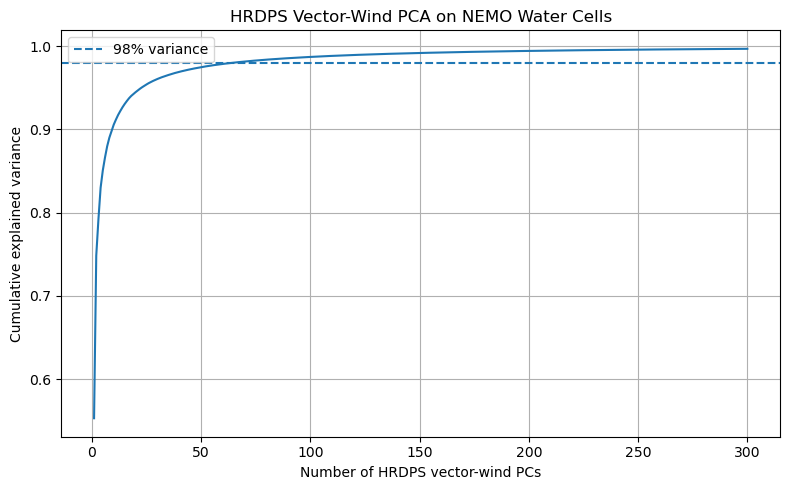

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(hrdps_cumulative_variance) + 1), hrdps_cumulative_variance)
plt.axhline(hrdps_variance_threshold, linestyle="--", label="98% variance")
plt.xlabel("Number of HRDPS vector-wind PCs")
plt.ylabel("Cumulative explained variance")
plt.title("HRDPS Vector-Wind PCA on NEMO Water Cells")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
threshold_indices = np.where(hrdps_cumulative_variance >= hrdps_variance_threshold)[0]

if threshold_indices.size == 0:
    n_hrdps_pcs = max_hrdps_pcs
    print("Warning: 98% variance was not reached within", max_hrdps_pcs, "PCs.")
    print("Using all searched PCs. Increase max_hrdps_pcs if 98% variance is required.")
else:
    n_hrdps_pcs = threshold_indices[0] + 1

print("Selected HRDPS PCs:", n_hrdps_pcs)
print("Cumulative variance:", hrdps_cumulative_variance[n_hrdps_pcs - 1])

Selected HRDPS PCs: 65
Cumulative variance: 0.98005927


In [33]:
hrdps_train_scores = hrdps_train_scores_all[:, :n_hrdps_pcs]
hrdps_val_scores = pca_hrdps.transform(X_hrdps_val)[:, :n_hrdps_pcs]
hrdps_test_scores = pca_hrdps.transform(X_hrdps_test)[:, :n_hrdps_pcs]

print("HRDPS train scores:", hrdps_train_scores.shape)
print("HRDPS val scores:", hrdps_val_scores.shape)
print("HRDPS test scores:", hrdps_test_scores.shape)

HRDPS train scores: (8760, 65)
HRDPS val scores: (2904, 65)
HRDPS test scores: (2912, 65)


In [34]:
max_canrcm_pcs = min(100, X_canrcm_train.shape[0] - 1, X_canrcm_train.shape[1])

pca_canrcm = PCA(n_components=max_canrcm_pcs, svd_solver="randomized", random_state=0)

canrcm_train_scores_all = pca_canrcm.fit_transform(X_canrcm_train)
canrcm_val_scores_all = pca_canrcm.transform(X_canrcm_val)
canrcm_test_scores_all = pca_canrcm.transform(X_canrcm_test)

canrcm_cumulative_variance = np.cumsum(pca_canrcm.explained_variance_ratio_)

print("CanRCM PCA components:", pca_canrcm.components_.shape)
print("CanRCM train scores:", canrcm_train_scores_all.shape)
print("CanRCM val scores:", canrcm_val_scores_all.shape)
print("CanRCM test scores:", canrcm_test_scores_all.shape)

CanRCM PCA components: (100, 680)
CanRCM train scores: (8760, 100)
CanRCM val scores: (2904, 100)
CanRCM test scores: (2912, 100)


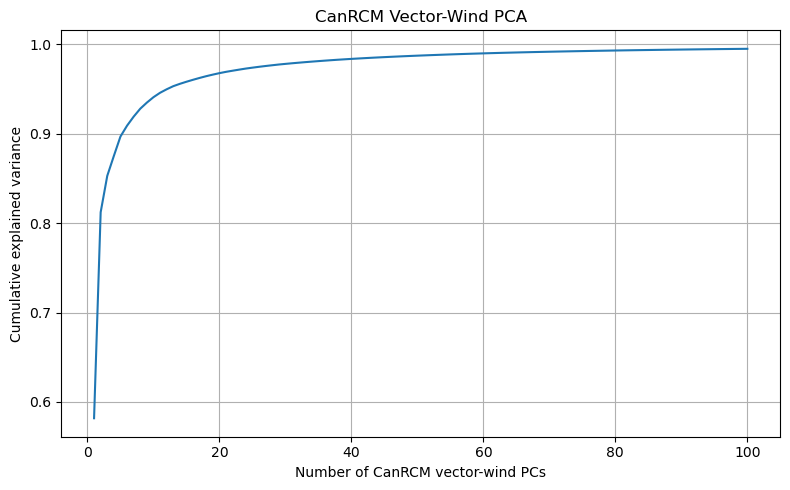

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(canrcm_cumulative_variance) + 1), canrcm_cumulative_variance)
plt.xlabel("Number of CanRCM vector-wind PCs")
plt.ylabel("Cumulative explained variance")
plt.title("CanRCM Vector-Wind PCA")
plt.grid(True)
plt.tight_layout()
plt.show()

In [36]:
canrcm_pc_candidates = range(1, max_canrcm_pcs + 1)

val_r2_scores = []

for n_canrcm_pcs_candidate in canrcm_pc_candidates:
    X_train_pc = canrcm_train_scores_all[:, :n_canrcm_pcs_candidate]
    X_val_pc = canrcm_val_scores_all[:, :n_canrcm_pcs_candidate]

    model = LinearRegression()
    model.fit(X_train_pc, hrdps_train_scores)

    hrdps_val_scores_pred_candidate = model.predict(X_val_pc)

    val_r2 = r2_score(hrdps_val_scores, hrdps_val_scores_pred_candidate, multioutput="variance_weighted")
    val_r2_scores.append(val_r2)

val_r2_scores = np.array(val_r2_scores)

In [37]:
best_index = np.nanargmax(val_r2_scores)
n_canrcm_pcs = list(canrcm_pc_candidates)[best_index]
best_val_r2 = val_r2_scores[best_index]
print("Best number of CanRCM PCs:", n_canrcm_pcs)
print("Best validation PC-space R²:", best_val_r2)

Best number of CanRCM PCs: 100
Best validation PC-space R²: 0.7054111957550049


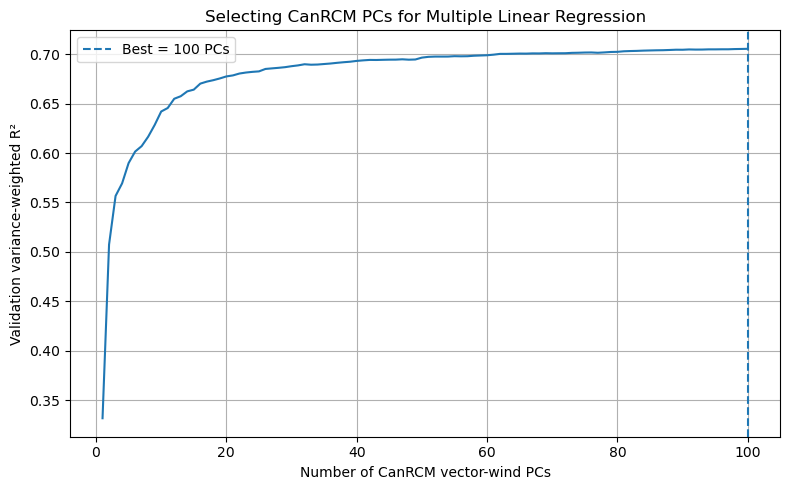

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(list(canrcm_pc_candidates), val_r2_scores)
plt.axvline(n_canrcm_pcs, linestyle="--", label=f"Best = {n_canrcm_pcs} PCs")
plt.xlabel("Number of CanRCM vector-wind PCs")
plt.ylabel("Validation variance-weighted R²")
plt.title("Selecting CanRCM PCs for Multiple Linear Regression")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [39]:
X_train_pc_final = canrcm_train_scores_all[:, :n_canrcm_pcs]
X_val_pc_final = canrcm_val_scores_all[:, :n_canrcm_pcs]
X_test_pc_final = canrcm_test_scores_all[:, :n_canrcm_pcs]
lr_model = LinearRegression()
lr_model.fit(X_train_pc_final, hrdps_train_scores)
hrdps_train_scores_pred = lr_model.predict(X_train_pc_final)
hrdps_val_scores_pred = lr_model.predict(X_val_pc_final)
hrdps_test_scores_pred = lr_model.predict(X_test_pc_final)
print("Regression coefficient shape:", lr_model.coef_.shape)
print("Predicted HRDPS train scores:", hrdps_train_scores_pred.shape)
print("Predicted HRDPS validation scores:", hrdps_val_scores_pred.shape)
print("Predicted HRDPS test scores:", hrdps_test_scores_pred.shape)

Regression coefficient shape: (65, 100)
Predicted HRDPS train scores: (8760, 65)
Predicted HRDPS validation scores: (2904, 65)
Predicted HRDPS test scores: (2912, 65)


In [40]:
def inverse_from_selected_hrdps_pcs(scores, pca, n_pcs):
    reconstructed = np.dot(scores, pca.components_[:n_pcs, :])
    reconstructed = reconstructed + pca.mean_
    return reconstructed.astype(np.float32)

In [41]:
X_hrdps_val_pred = inverse_from_selected_hrdps_pcs(hrdps_val_scores_pred, pca_hrdps, n_hrdps_pcs)
X_hrdps_test_pred = inverse_from_selected_hrdps_pcs(hrdps_test_scores_pred, pca_hrdps, n_hrdps_pcs)
print("Actual validation matrix:", X_hrdps_val.shape)
print("Predicted validation matrix:", X_hrdps_val_pred.shape)
print("Actual test matrix:", X_hrdps_test.shape)
print("Predicted test matrix:", X_hrdps_test_pred.shape)

Actual validation matrix: (2904, 162766)
Predicted validation matrix: (2904, 162766)
Actual test matrix: (2912, 162766)
Predicted test matrix: (2912, 162766)


In [42]:
# The first half is u_wind.
# The second half is v_wind.
X_hrdps_u_val_pred = X_hrdps_val_pred[:, :n_hrdps_cells]
X_hrdps_v_val_pred = X_hrdps_val_pred[:, n_hrdps_cells:]
X_hrdps_u_test_pred = X_hrdps_test_pred[:, :n_hrdps_cells]
X_hrdps_v_test_pred = X_hrdps_test_pred[:, n_hrdps_cells:]
print("Predicted validation U:", X_hrdps_u_val_pred.shape)
print("Predicted validation V:", X_hrdps_v_val_pred.shape)
print("Predicted test U:", X_hrdps_u_test_pred.shape)
print("Predicted test V:", X_hrdps_v_test_pred.shape)

Predicted validation U: (2904, 81383)
Predicted validation V: (2904, 81383)
Predicted test U: (2912, 81383)
Predicted test V: (2912, 81383)


In [43]:
def calculate_metrics(actual, predicted, label, unit="m/s"):
    rmse = np.sqrt(mean_squared_error(actual.ravel(), predicted.ravel()))
    mae = mean_absolute_error(actual.ravel(), predicted.ravel())
    bias = np.mean(predicted - actual)
    r2 = r2_score(actual, predicted, multioutput="variance_weighted")
    print(f"\n{label}")
    print("RMSE:", rmse, unit)
    print("MAE:", mae, unit)
    print("Bias:", bias, unit)
    print("R²:", r2)
    return {"RMSE": rmse, "MAE": mae, "Bias": bias, "R2": r2}

In [44]:
val_u_metrics = calculate_metrics(X_hrdps_u_val, X_hrdps_u_val_pred, "Validation U-wind metrics on NEMO water cells")
val_v_metrics = calculate_metrics(X_hrdps_v_val, X_hrdps_v_val_pred, "Validation V-wind metrics on NEMO water cells")
test_u_metrics = calculate_metrics(X_hrdps_u_test, X_hrdps_u_test_pred, "Test U-wind metrics on NEMO water cells")
test_v_metrics = calculate_metrics(X_hrdps_v_test, X_hrdps_v_test_pred, "Test V-wind metrics on NEMO water cells")


Validation U-wind metrics on NEMO water cells
RMSE: 2.155312707609786 m/s
MAE: 1.5314338207244873 m/s
Bias: 0.0030758001 m/s
R²: 0.6983296871185303

Validation V-wind metrics on NEMO water cells
RMSE: 1.712994458173438 m/s
MAE: 1.247604250907898 m/s
Bias: 0.030669693 m/s
R²: 0.6765011548995972

Test U-wind metrics on NEMO water cells
RMSE: 2.14056808507395 m/s
MAE: 1.564742088317871 m/s
Bias: 0.05226408 m/s
R²: 0.7171143889427185

Test V-wind metrics on NEMO water cells
RMSE: 1.7711106550691262 m/s
MAE: 1.3267165422439575 m/s
Bias: -0.20097633 m/s
R²: 0.6945397257804871


In [45]:
hrdps_speed_val = np.sqrt(X_hrdps_u_val**2 + X_hrdps_v_val**2)
hrdps_speed_val_pred = np.sqrt(X_hrdps_u_val_pred**2 + X_hrdps_v_val_pred**2)
hrdps_speed_test = np.sqrt(X_hrdps_u_test**2 + X_hrdps_v_test**2)
hrdps_speed_test_pred = np.sqrt(X_hrdps_u_test_pred**2 + X_hrdps_v_test_pred**2)
val_speed_metrics = calculate_metrics(hrdps_speed_val, hrdps_speed_val_pred, "Validation wind-speed metrics on NEMO water cells")
test_speed_metrics = calculate_metrics(hrdps_speed_test, hrdps_speed_test_pred, "Test wind-speed metrics on NEMO water cells")


Validation wind-speed metrics on NEMO water cells
RMSE: 2.0080462961597156 m/s
MAE: 1.466246247291565 m/s
Bias: -0.59196883 m/s
R²: 0.463500052690506

Test wind-speed metrics on NEMO water cells
RMSE: 2.0524262143438743 m/s
MAE: 1.5372960567474365 m/s
Bias: -0.7240997 m/s
R²: 0.5016036033630371


In [46]:
val_vector_rmse = np.sqrt(np.mean((X_hrdps_u_val_pred - X_hrdps_u_val)**2 + (X_hrdps_v_val_pred - X_hrdps_v_val)**2))
test_vector_rmse = np.sqrt(np.mean((X_hrdps_u_test_pred - X_hrdps_u_test)**2 + (X_hrdps_v_test_pred - X_hrdps_v_test)**2))
print("Validation vector RMSE:", val_vector_rmse, "m/s")
print("Test vector RMSE:", test_vector_rmse, "m/s")

Validation vector RMSE: 2.7531297 m/s
Test vector RMSE: 2.7782845 m/s


In [47]:
test_pc_r2 = r2_score(
    hrdps_test_scores,
    hrdps_test_scores_pred,
    multioutput="variance_weighted",
)

print(
    "Test PC-space "
    "variance-weighted R²:",
    test_pc_r2,
)

Test PC-space variance-weighted R²: 0.7276452779769897


In [48]:
def nemo_vector_to_map(vector):
    nemo_map = np.full(water_mask.shape, np.nan, dtype=np.float32)
    nemo_map[valid_nemo_j, valid_nemo_i] = vector
    return nemo_map

In [49]:
def plot_actual_predicted_error(time_index, X_actual, X_predicted, times, variable_label, unit="m/s"):
    actual_map = nemo_vector_to_map(X_actual[time_index])
    predicted_map = nemo_vector_to_map(X_predicted[time_index])
    error_map = predicted_map - actual_map
    value_min = np.nanmin(np.stack([actual_map, predicted_map]))
    value_max = np.nanmax(np.stack([actual_map, predicted_map]))
    error_limit = np.nanmax(np.abs(error_map))
    timestamp = pd.Timestamp(times[time_index])
    fig, axes = plt.subplots(1, 3, figsize=(18, 8))
    p0 = axes[0].pcolormesh(actual_map, shading="auto", vmin=value_min, vmax=value_max)
    axes[0].set_title(f"Actual HRDPS on NEMO Grid\n{timestamp}")
    plt.colorbar(p0, ax=axes[0], label=f"{variable_label} ({unit})")
    p1 = axes[1].pcolormesh(predicted_map, shading="auto", vmin=value_min, vmax=value_max)
    axes[1].set_title(f"Predicted PCA + MLR\n{timestamp}")
    plt.colorbar(p1, ax=axes[1], label=f"{variable_label} ({unit})")
    p2 = axes[2].pcolormesh(error_map, shading="auto", cmap="RdBu_r", vmin=-error_limit, vmax=error_limit)
    axes[2].set_title(f"Predicted - Actual\n{timestamp}")
    plt.colorbar(p2, ax=axes[2], label=f"Error ({unit})")
    for ax in axes:
        ax.set_xlabel("NEMO x index (i)")
        ax.set_ylabel("NEMO y index (j)")
    fig.suptitle(variable_label, fontsize=15)
    plt.tight_layout()
    plt.show()

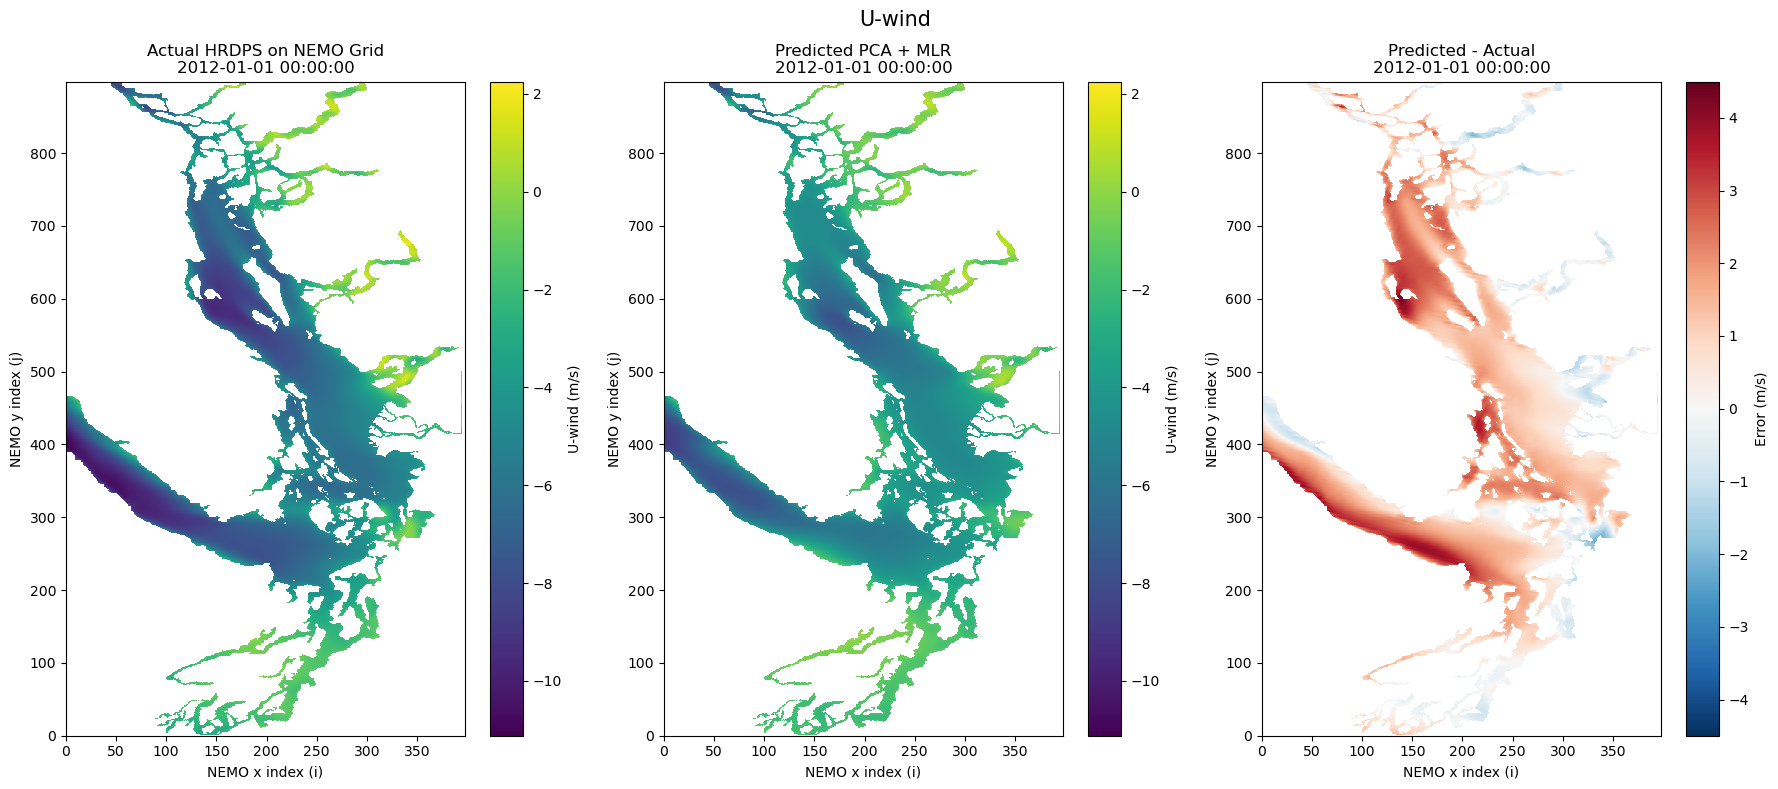

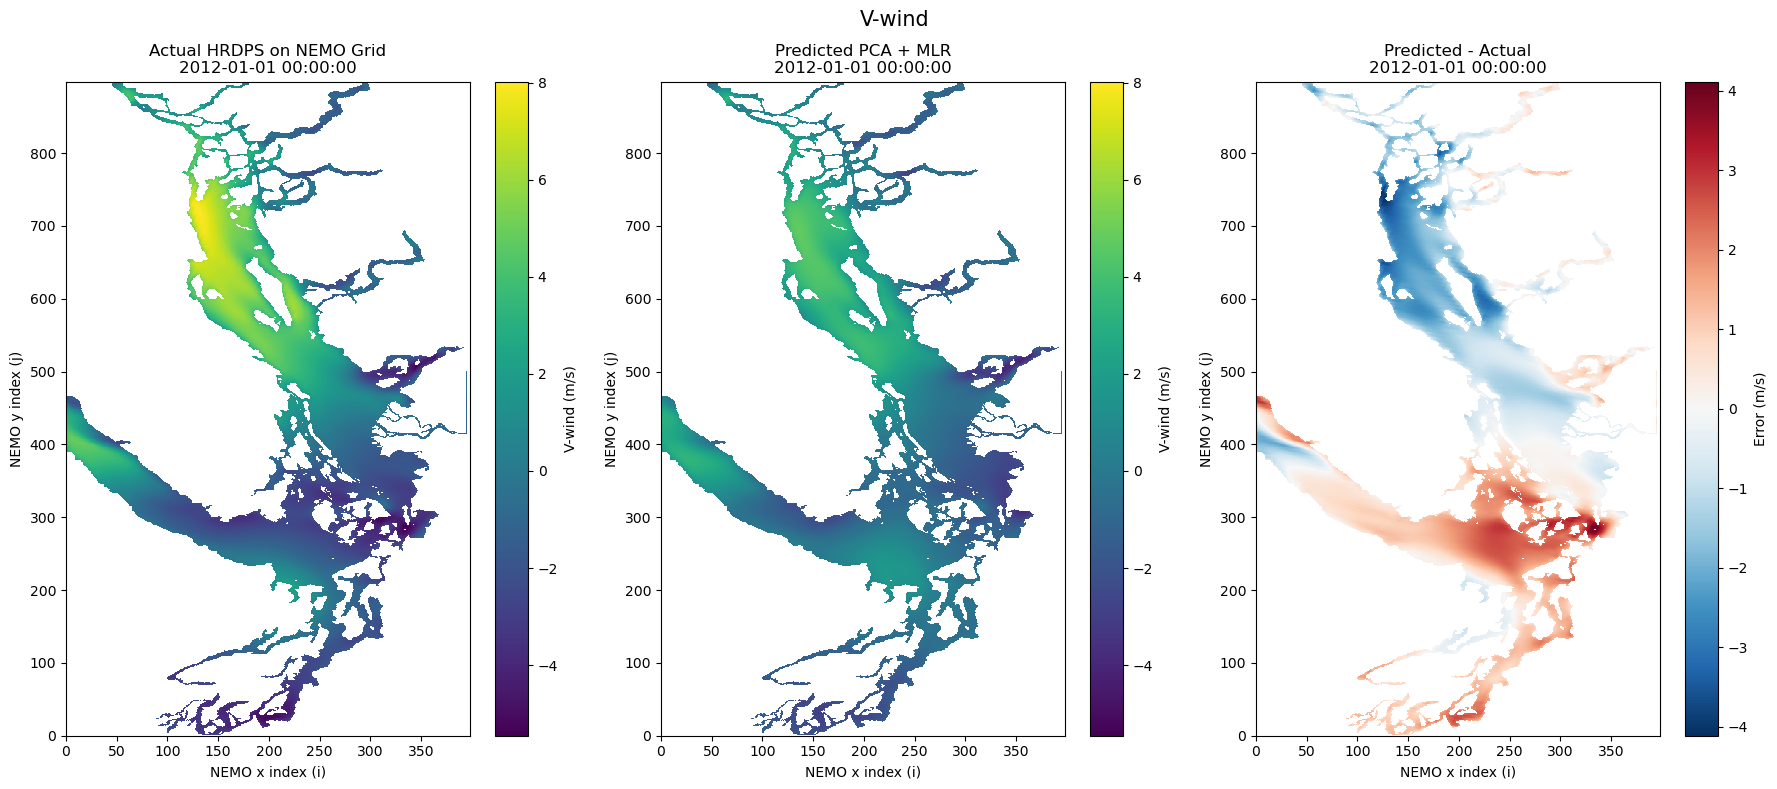

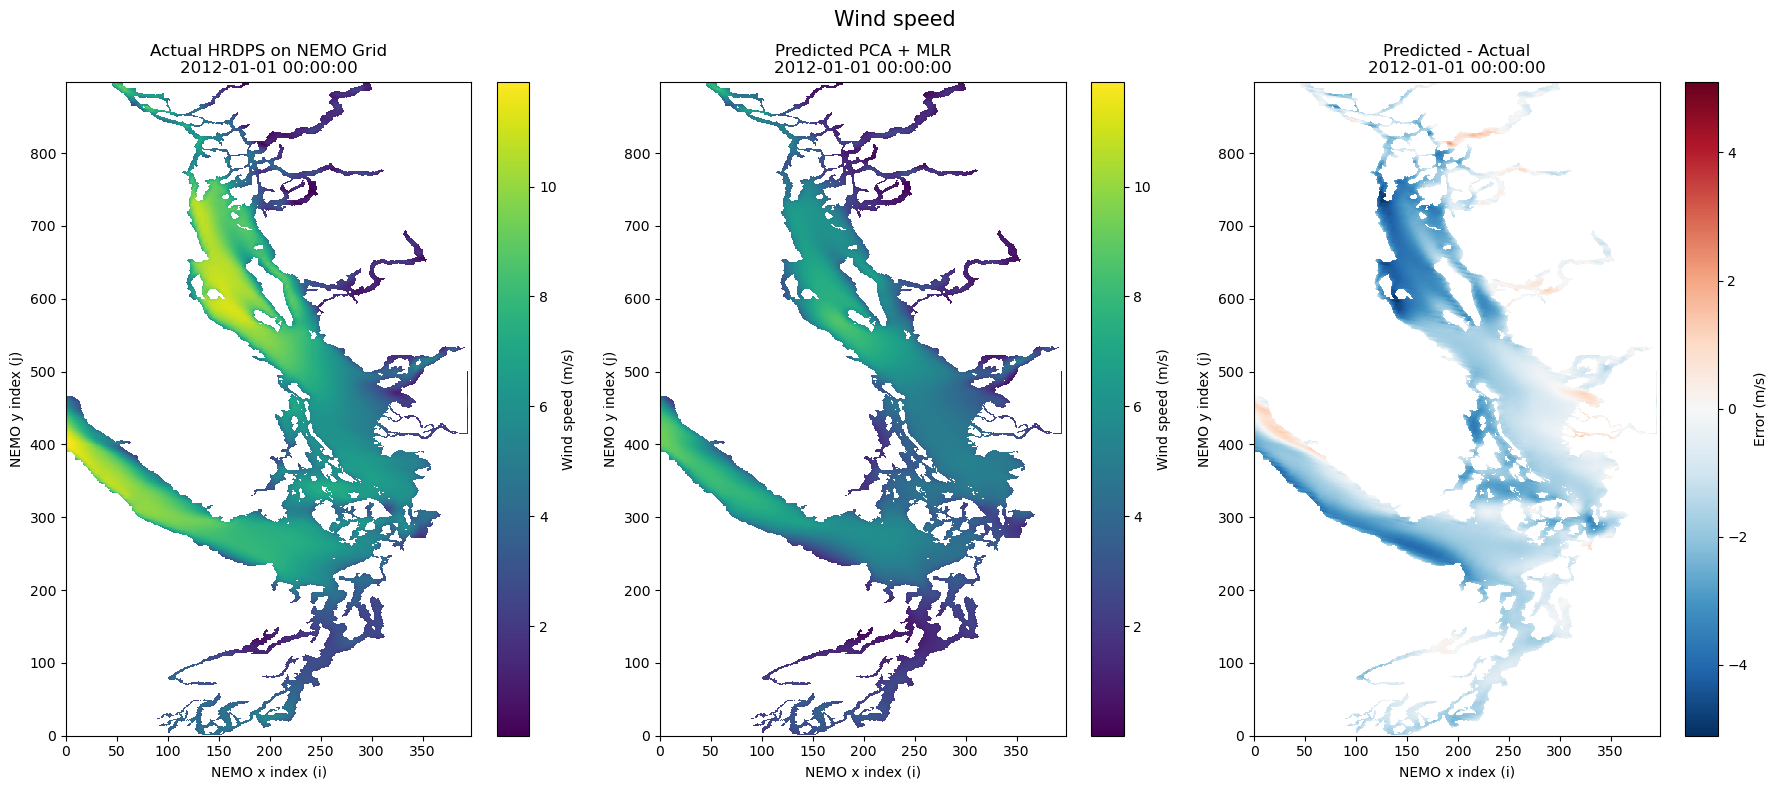

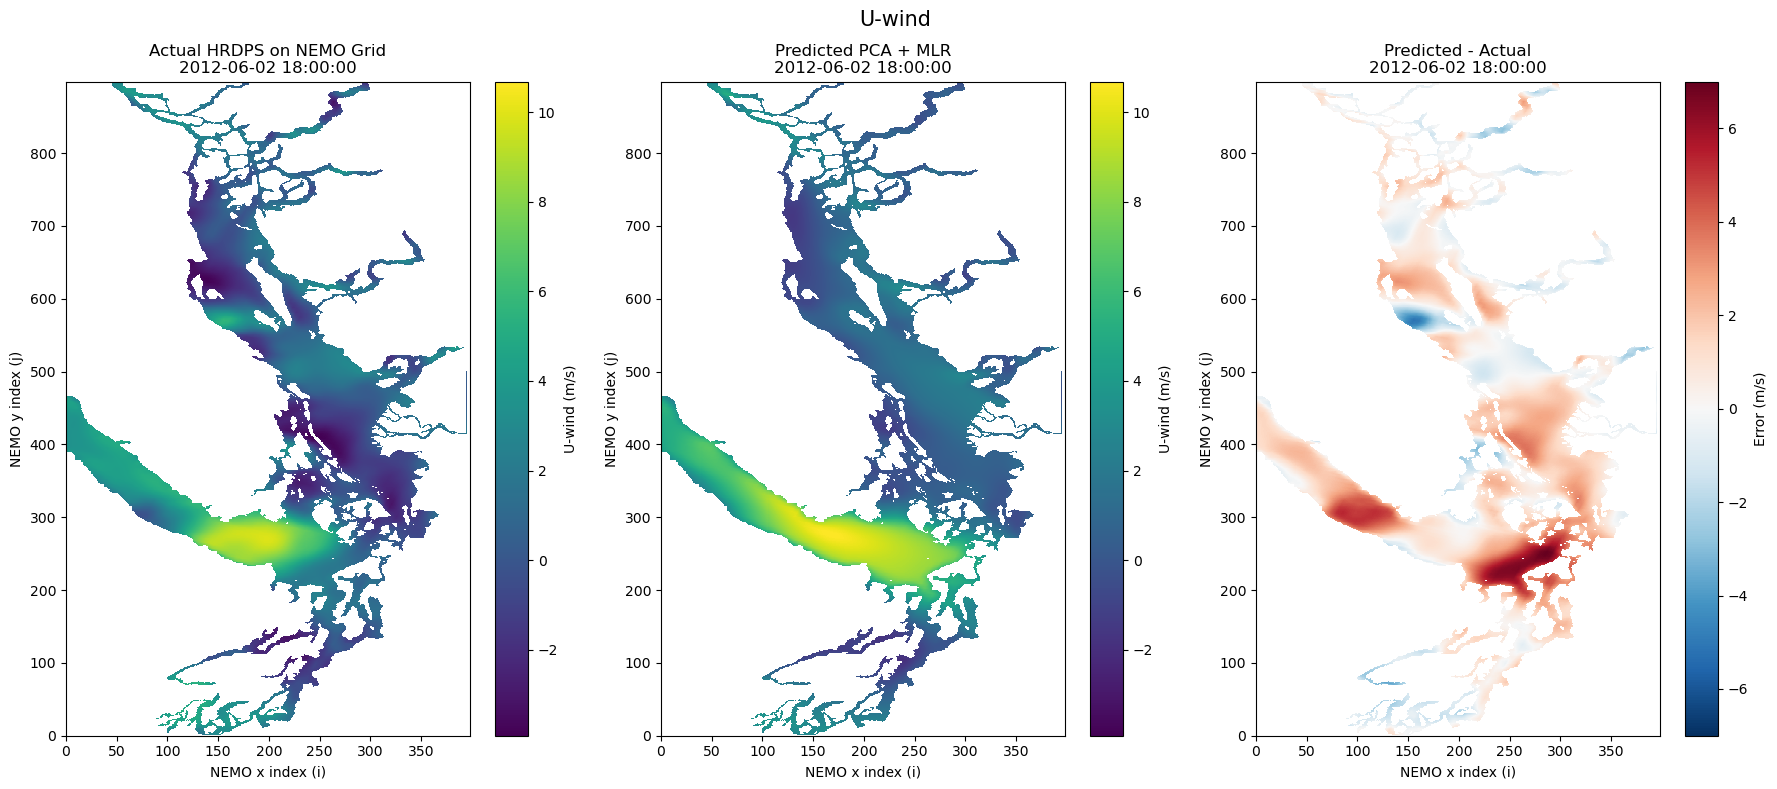

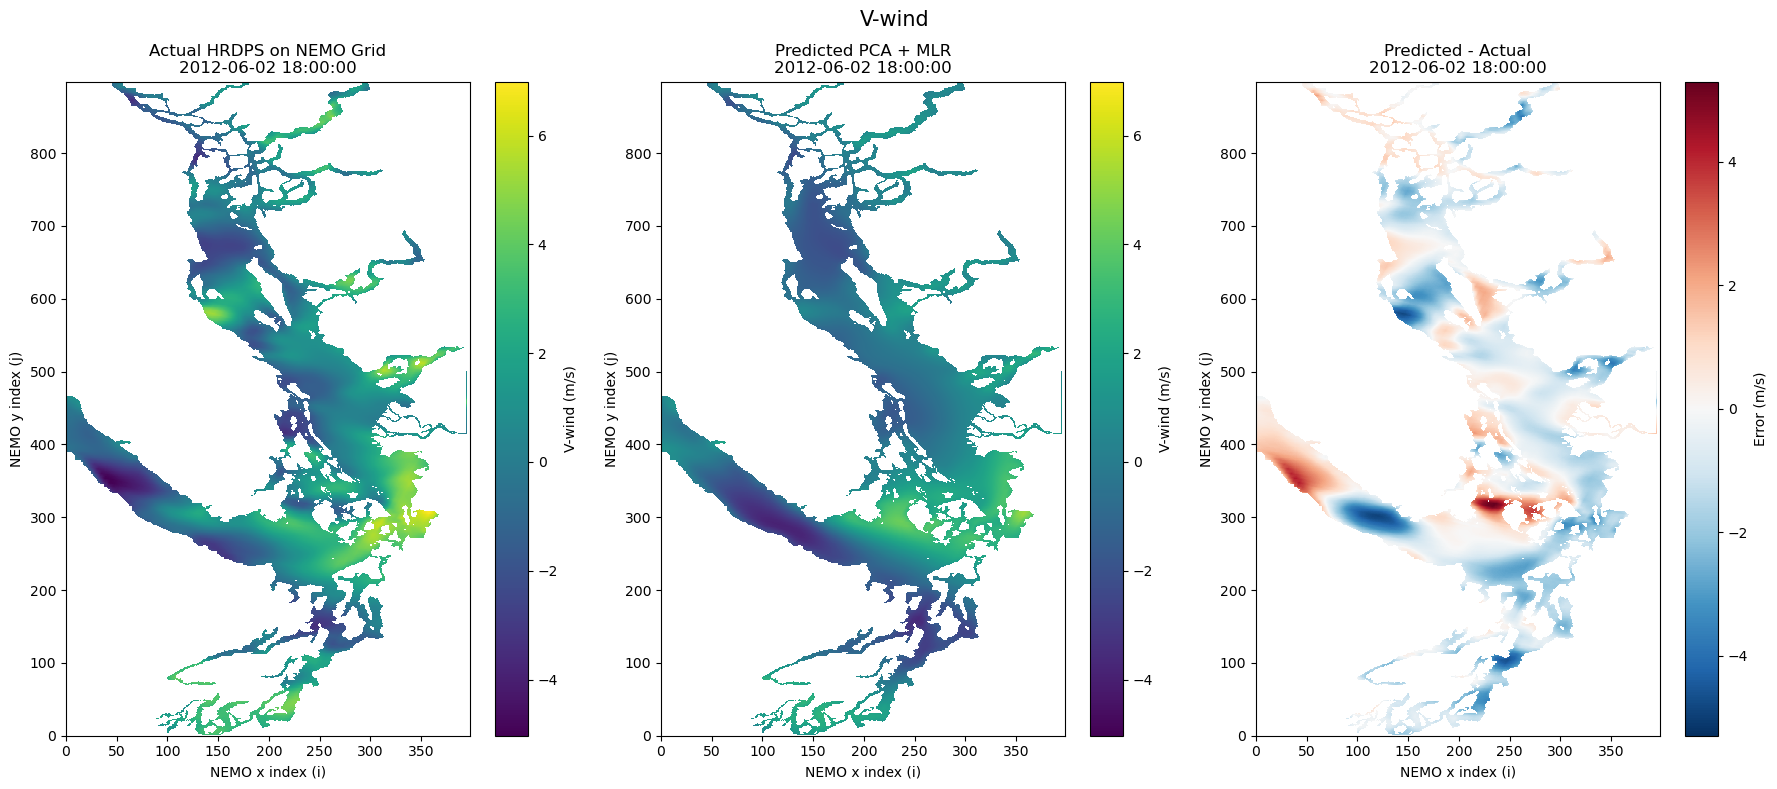

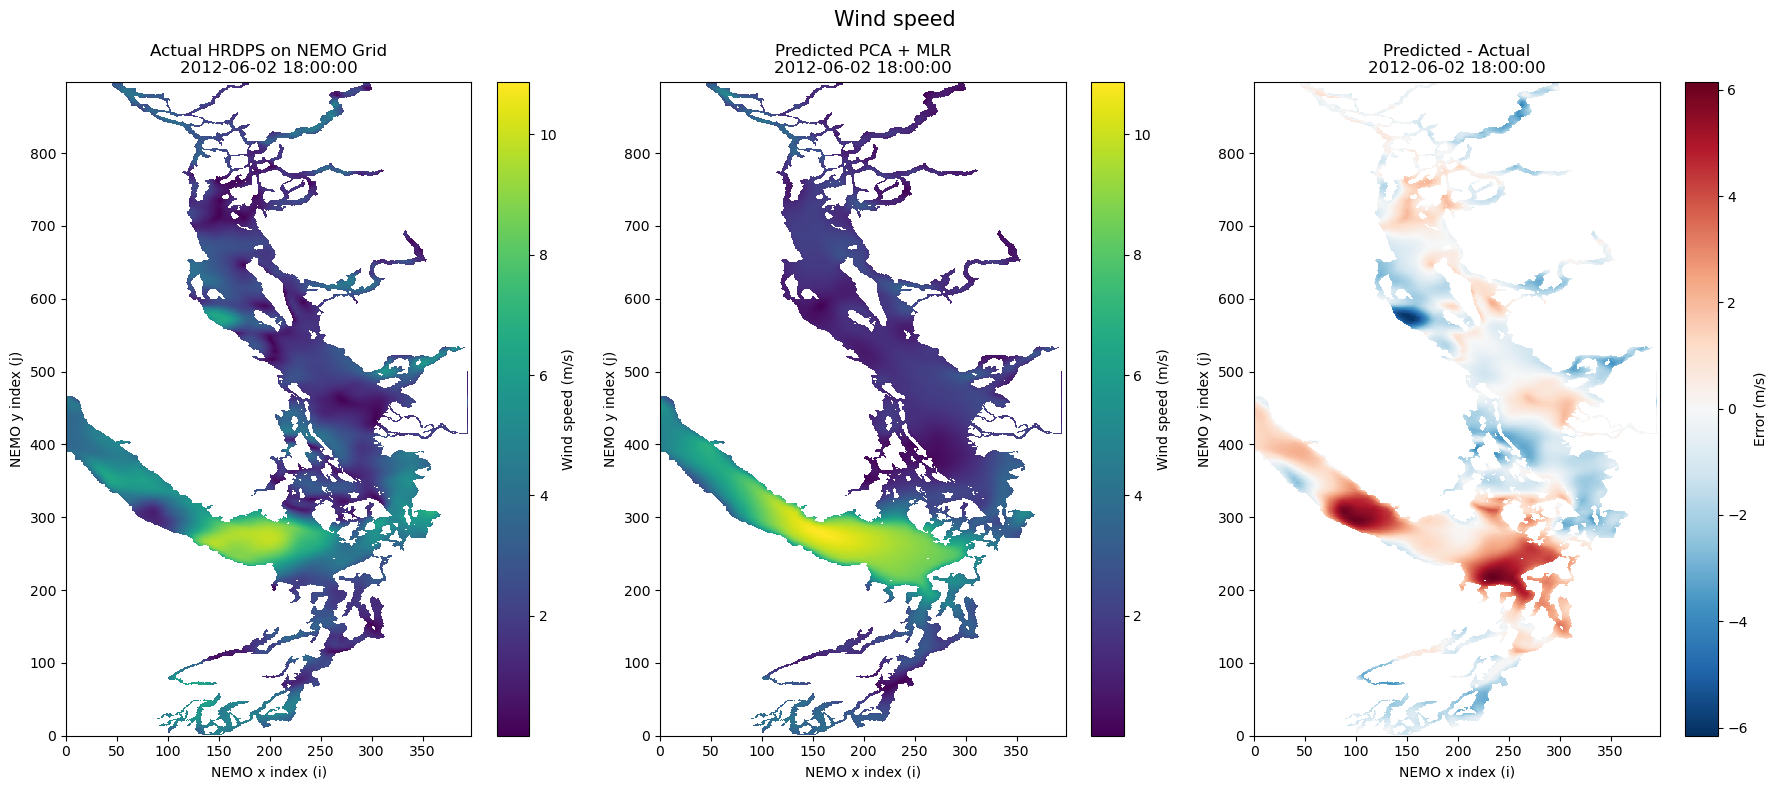

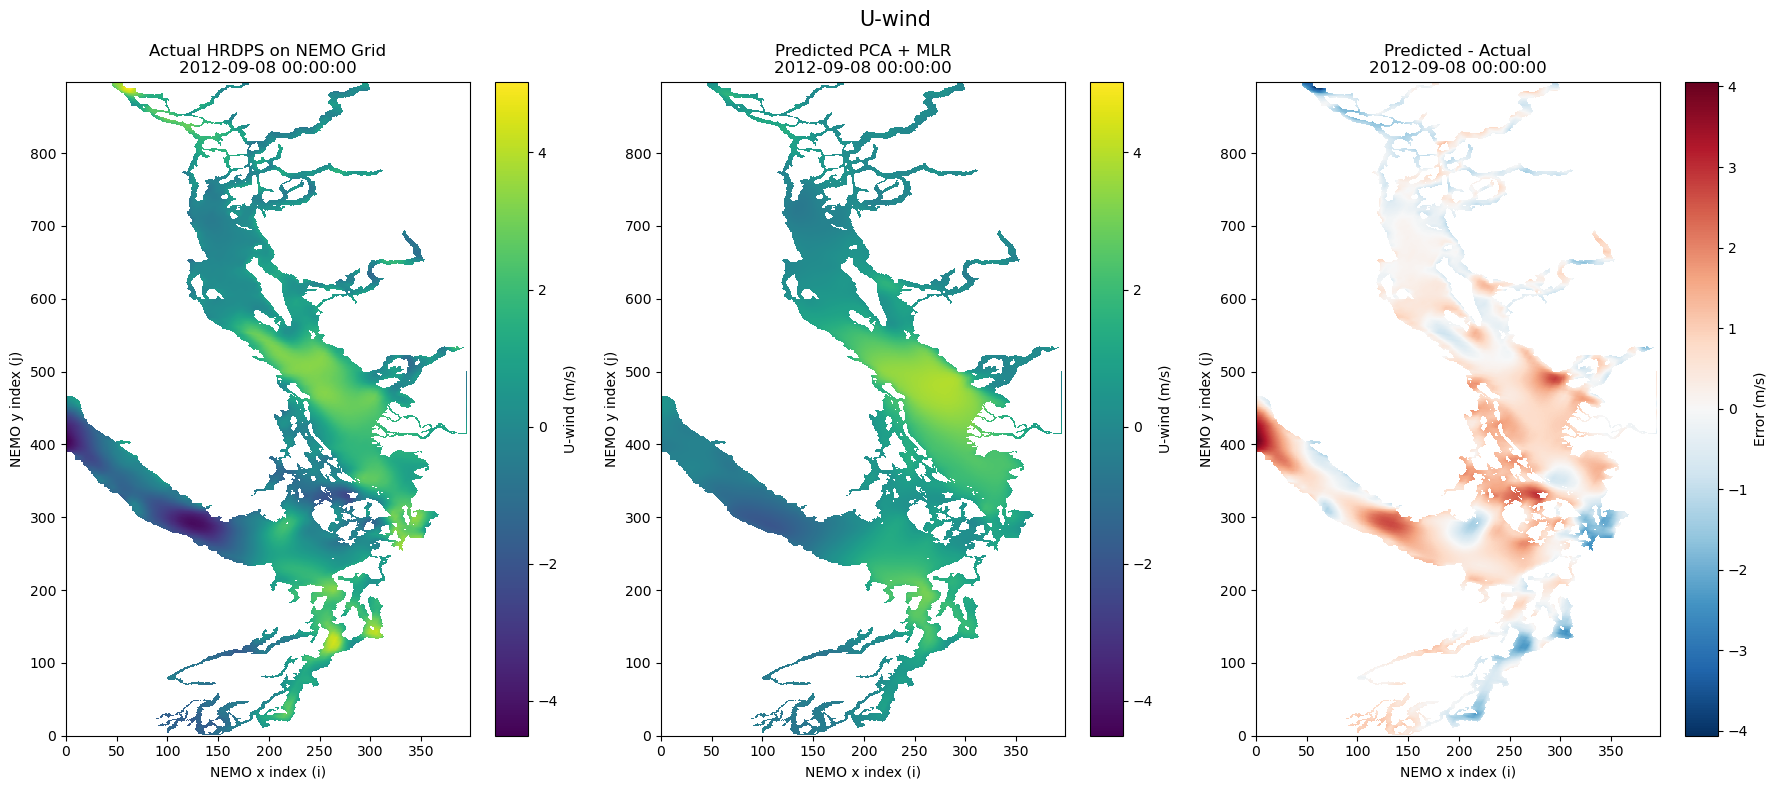

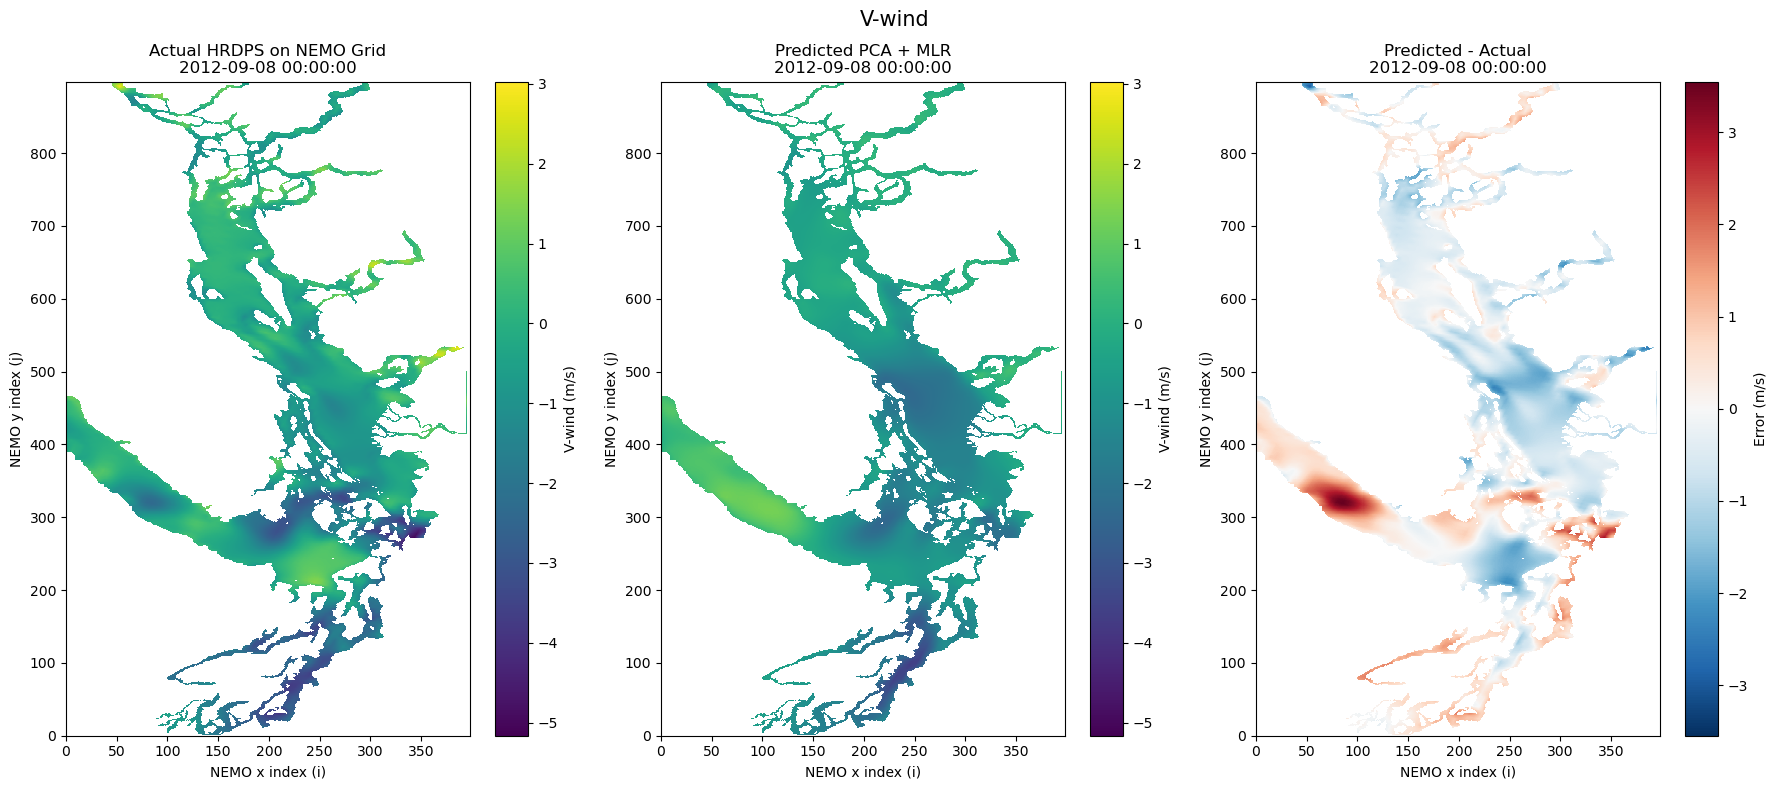

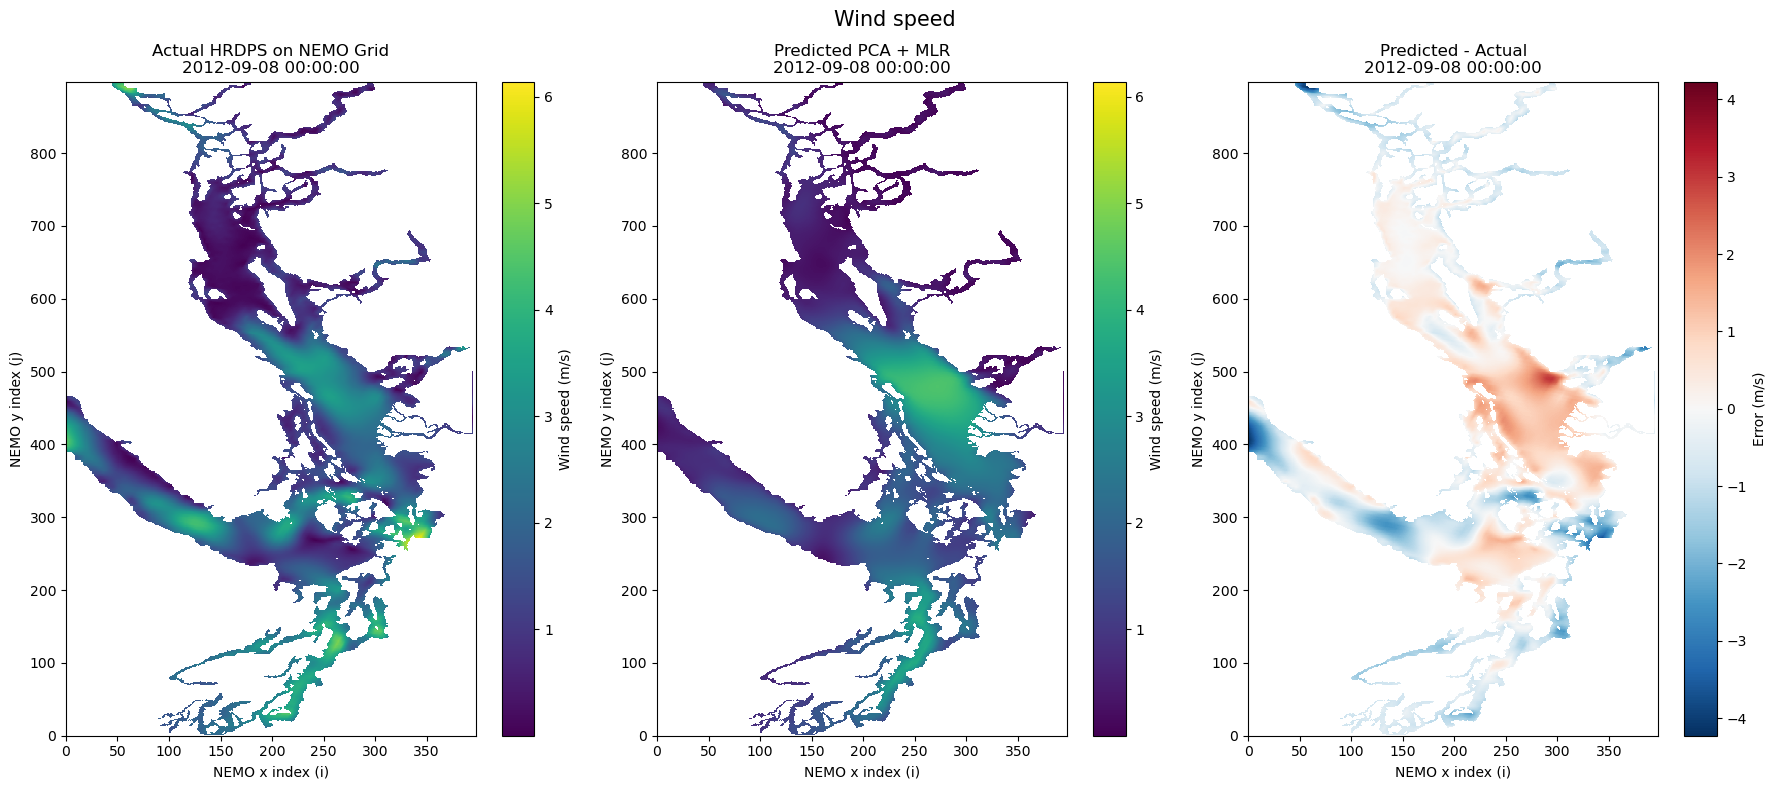

In [50]:
test_times = ds_hrdps_test["time_counter"].values
plot_time_indices = [0, 1222, 2000]
for time_index in plot_time_indices:
    plot_actual_predicted_error(time_index=time_index, X_actual=X_hrdps_u_test, X_predicted=X_hrdps_u_test_pred, times=test_times, variable_label="U-wind")
    plot_actual_predicted_error(time_index=time_index, X_actual=X_hrdps_v_test, X_predicted=X_hrdps_v_test_pred, times=test_times, variable_label="V-wind")
    plot_actual_predicted_error(time_index=time_index, X_actual=hrdps_speed_test, X_predicted=hrdps_speed_test_pred, times=test_times, variable_label="Wind speed")

In [51]:
def make_spatial_mean_timeseries(actual_matrix, predicted_matrix, times):
    actual_mean = np.mean(actual_matrix, axis=1)
    predicted_mean = np.mean(predicted_matrix, axis=1)
    timeseries = pd.DataFrame({"actual": actual_mean, "predicted": predicted_mean}, index=pd.to_datetime(times))
    timeseries.index.name = "Date"
    return timeseries

def plot_spatial_mean_timeseries(timeseries, start_date, end_date, variable_label, split_label, unit="m/s"):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(timeseries.index, timeseries["actual"], label="Actual HRDPS on NEMO grid", linewidth=1.2)
    ax.plot(timeseries.index, timeseries["predicted"], label="Predicted PCA + MLR", linewidth=1.2, alpha=0.7)
    ax.set_xlim(pd.Timestamp(start_date), pd.Timestamp(end_date))
    ax.set_xlabel("Date")
    ax.set_ylabel(f"Spatial mean {variable_label} ({unit})")
    ax.set_title(f"Actual vs Predicted {variable_label} - {split_label}")
    ax.legend()
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

In [52]:
val_times = ds_hrdps_val["time_counter"].values
test_times = ds_hrdps_test["time_counter"].values
u_timeseries_2008 = make_spatial_mean_timeseries(X_hrdps_u_val, X_hrdps_u_val_pred, val_times)
v_timeseries_2008 = make_spatial_mean_timeseries(X_hrdps_v_val, X_hrdps_v_val_pred, val_times)
speed_timeseries_2008 = make_spatial_mean_timeseries(hrdps_speed_val, hrdps_speed_val_pred, val_times)
u_timeseries_2012 = make_spatial_mean_timeseries(X_hrdps_u_test, X_hrdps_u_test_pred, test_times)
v_timeseries_2012 = make_spatial_mean_timeseries(X_hrdps_v_test, X_hrdps_v_test_pred, test_times)
speed_timeseries_2012 = make_spatial_mean_timeseries(hrdps_speed_test, hrdps_speed_test_pred, test_times)

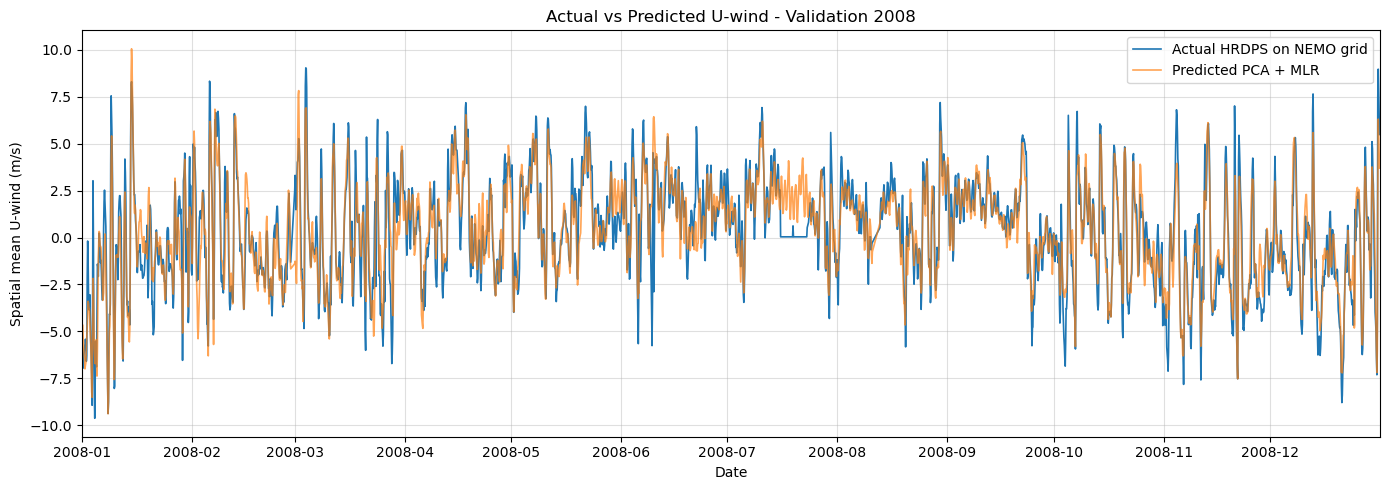

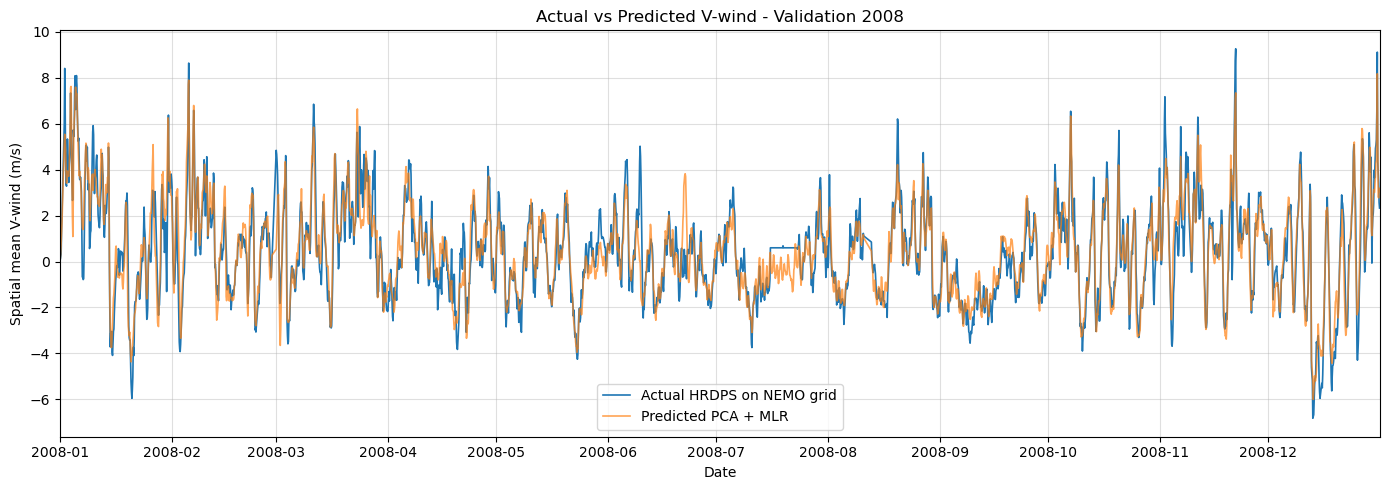

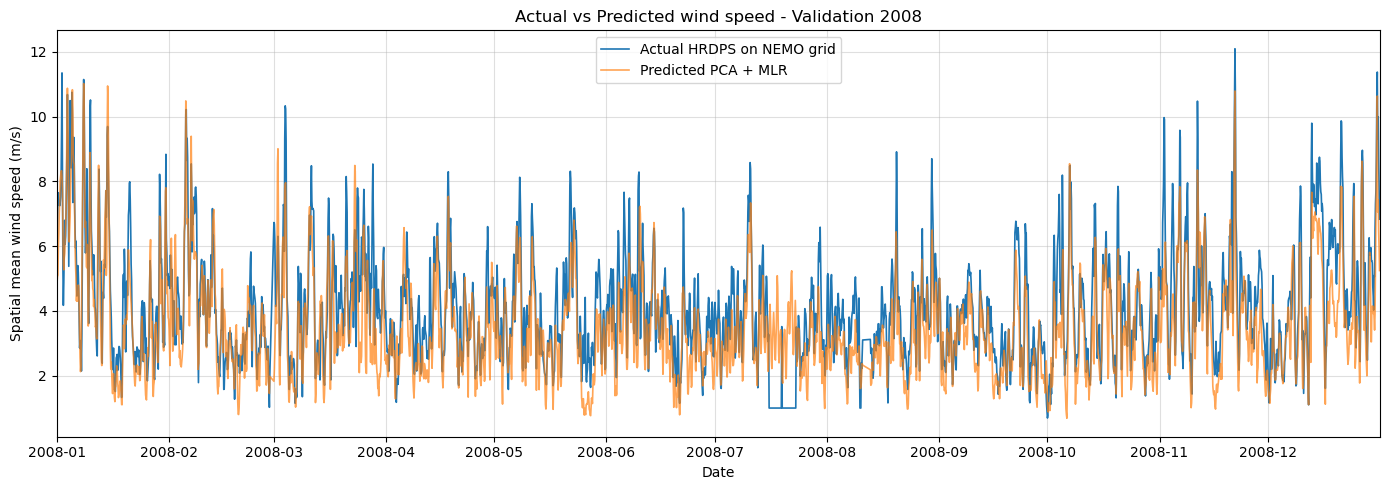

In [53]:
for timeseries, variable_label in [(u_timeseries_2008, "U-wind"), (v_timeseries_2008, "V-wind"), (speed_timeseries_2008, "wind speed")]:
    plot_spatial_mean_timeseries(timeseries=timeseries,
                                  start_date="2008-01-01",
                                    end_date="2008-12-31 23:59:59", variable_label=variable_label, split_label="Validation 2008")

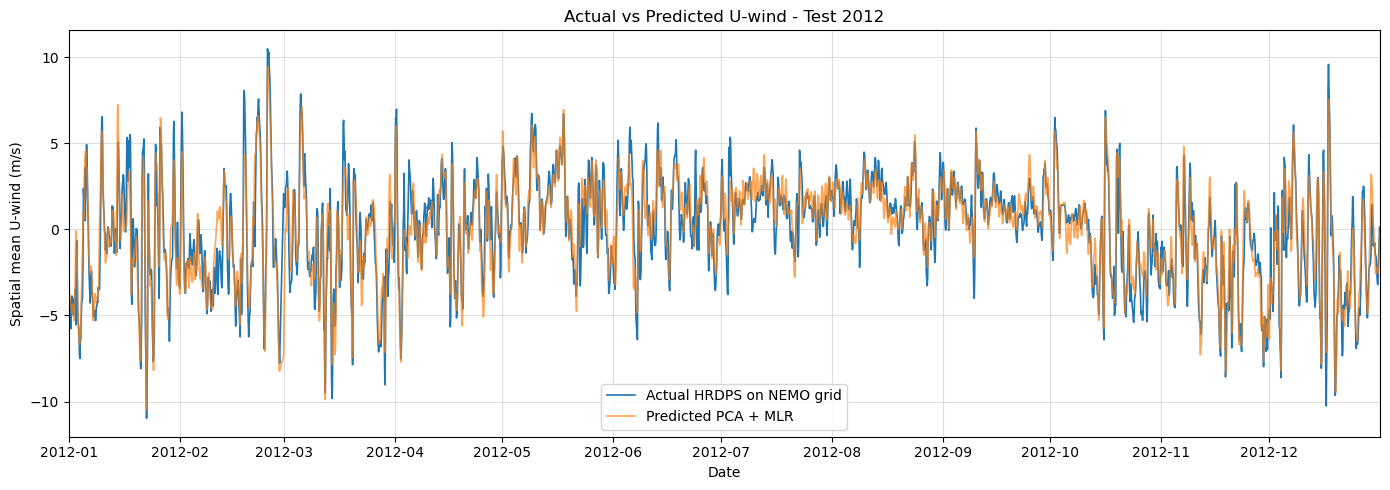

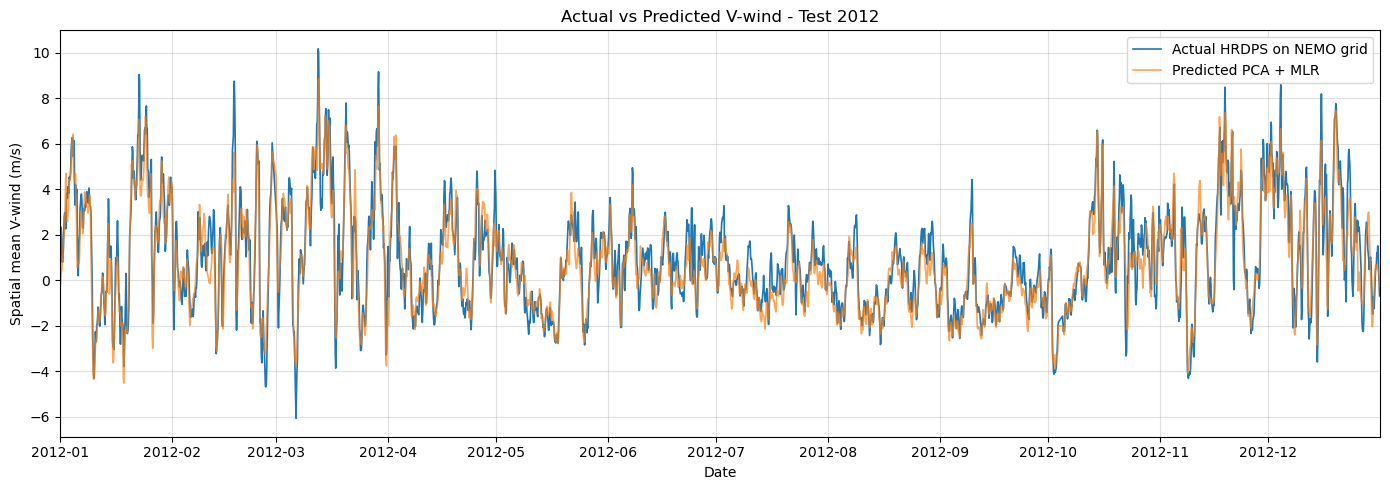

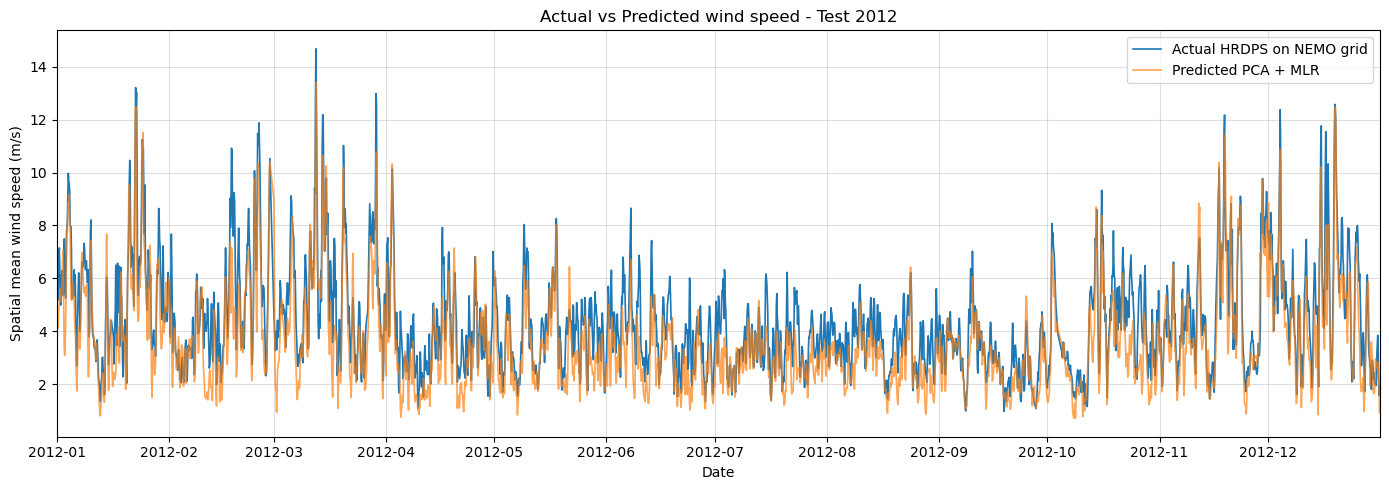

In [54]:
for timeseries, variable_label in [(u_timeseries_2012, "U-wind"), (v_timeseries_2012, "V-wind"), (speed_timeseries_2012, "wind speed")]:
    plot_spatial_mean_timeseries(timeseries=timeseries, 
                                 start_date="2012-01-01", 
                                 end_date="2012-12-31 23:59:59", variable_label=variable_label, split_label="Test 2012")

In [55]:
stations = {
    "Sand Heads": {"j": 426, "i": 293},
    "Halibut Bank": {"j": 503, "i": 261},
    "Sentry Shoal": {"j": 707, "i": 145},
}

In [56]:
def find_station_column(station_j, station_i):
    matches = np.where((valid_nemo_j == station_j) & (valid_nemo_i == station_i))[0]
    if len(matches) == 0:
        raise ValueError(f"Station cell j={station_j}, i={station_i} was not retained in valid_nemo_cols.")
    return int(matches[0])
for station_name, station_info in stations.items():
    column = find_station_column(station_info["j"], station_info["i"])
    stations[station_name]["column"] = column
    print(station_name, "j =", station_info["j"], "i =", station_info["i"], "matrix column =", column)

Sand Heads j = 426 i = 293 matrix column = 44165
Halibut Bank j = 503 i = 261 matrix column = 53329
Sentry Shoal j = 707 i = 145 matrix column = 71870


In [57]:
test_times = pd.to_datetime(ds_hrdps_test["time_counter"].values)
station_timeseries = {}
station_metrics = []
for station_name, station_info in stations.items():
    column = station_info["column"]
    actual_u = X_hrdps_u_test[:, column]
    predicted_u = X_hrdps_u_test_pred[:, column]
    actual_v = X_hrdps_v_test[:, column]
    predicted_v = X_hrdps_v_test_pred[:, column]
    actual_speed = np.sqrt(actual_u**2 + actual_v**2)
    predicted_speed = np.sqrt(predicted_u**2 + predicted_v**2)
    station_df = pd.DataFrame({"actual_u": actual_u, "predicted_u": predicted_u, "actual_v": actual_v, "predicted_v": predicted_v, "actual_speed": actual_speed, "predicted_speed": predicted_speed}, index=test_times)
    station_df.index.name = "Date"
    rmse_u = np.sqrt(mean_squared_error(actual_u, predicted_u))
    rmse_v = np.sqrt(mean_squared_error(actual_v, predicted_v))
    rmse_speed = np.sqrt(mean_squared_error(actual_speed, predicted_speed))
    vector_rmse = np.sqrt(np.mean((predicted_u - actual_u)**2 + (predicted_v - actual_v)**2))
    station_timeseries[station_name] = station_df
    station_metrics.append({"Station": station_name, "RMSE_u_mps": rmse_u, "RMSE_v_mps": rmse_v, "RMSE_speed_mps": rmse_speed, "Vector_RMSE_mps": vector_rmse})
station_rmse_table = pd.DataFrame(station_metrics)
print(station_rmse_table.to_string(index=False))

     Station  RMSE_u_mps  RMSE_v_mps  RMSE_speed_mps  Vector_RMSE_mps
  Sand Heads    2.651615    1.989552        2.277686         3.315023
Halibut Bank    3.043886    1.660459        2.549617         3.467329
Sentry Shoal    2.081381    2.140966        2.354094         2.985947


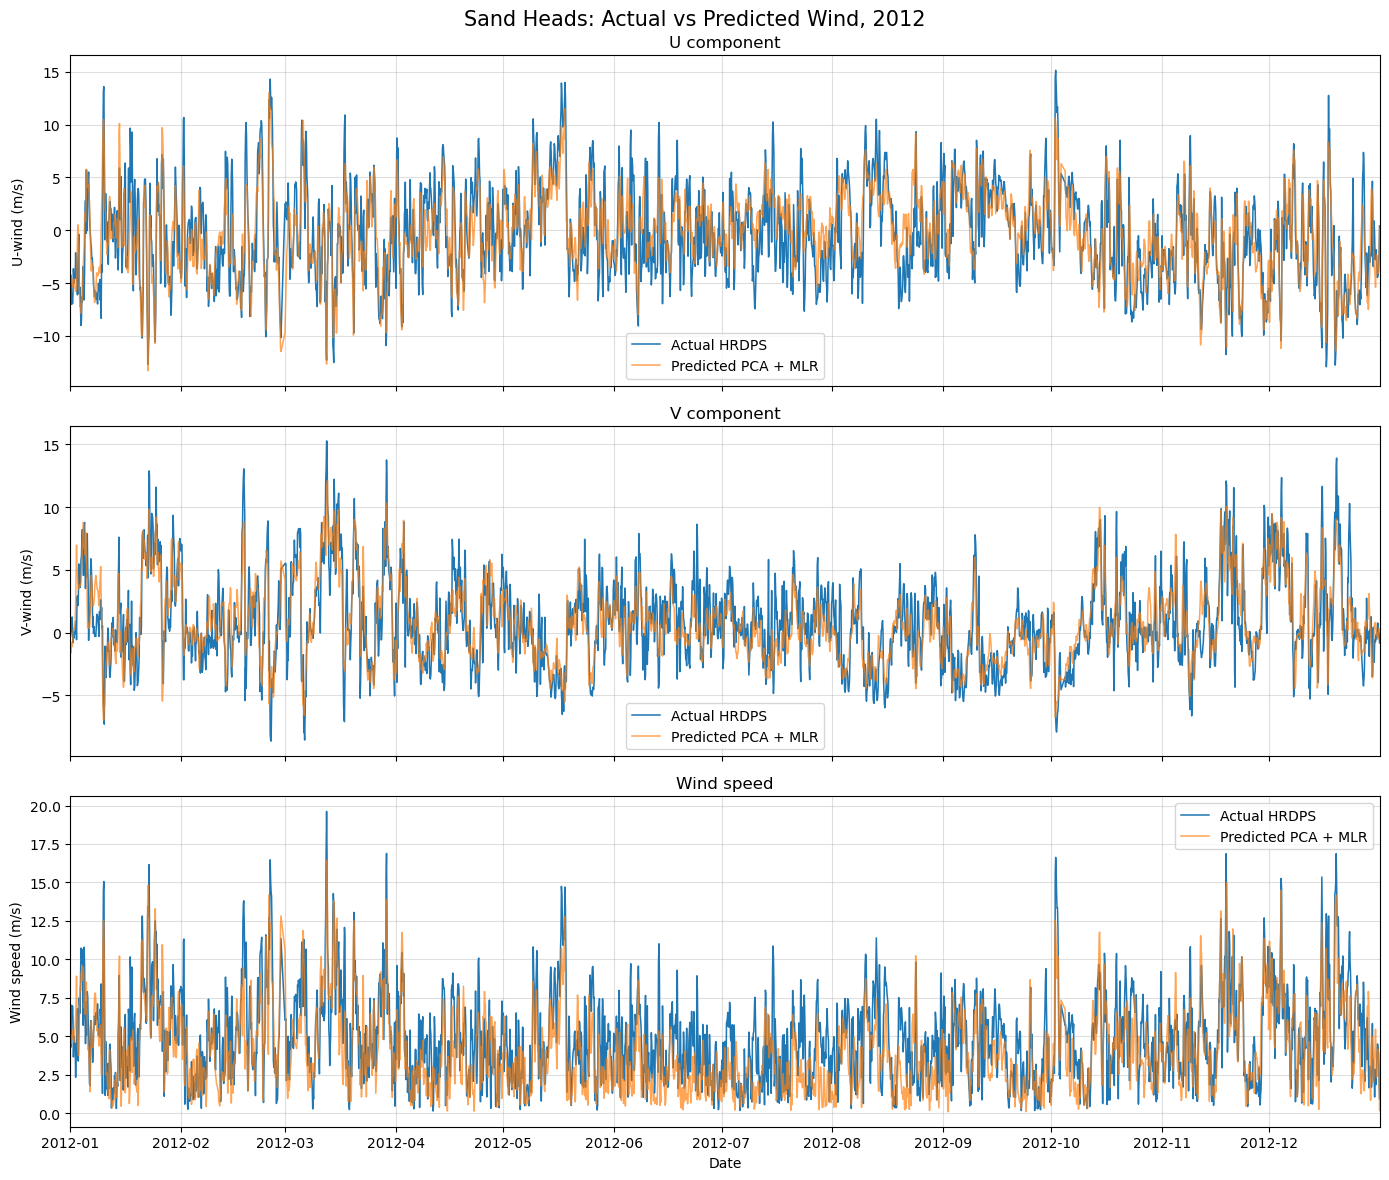

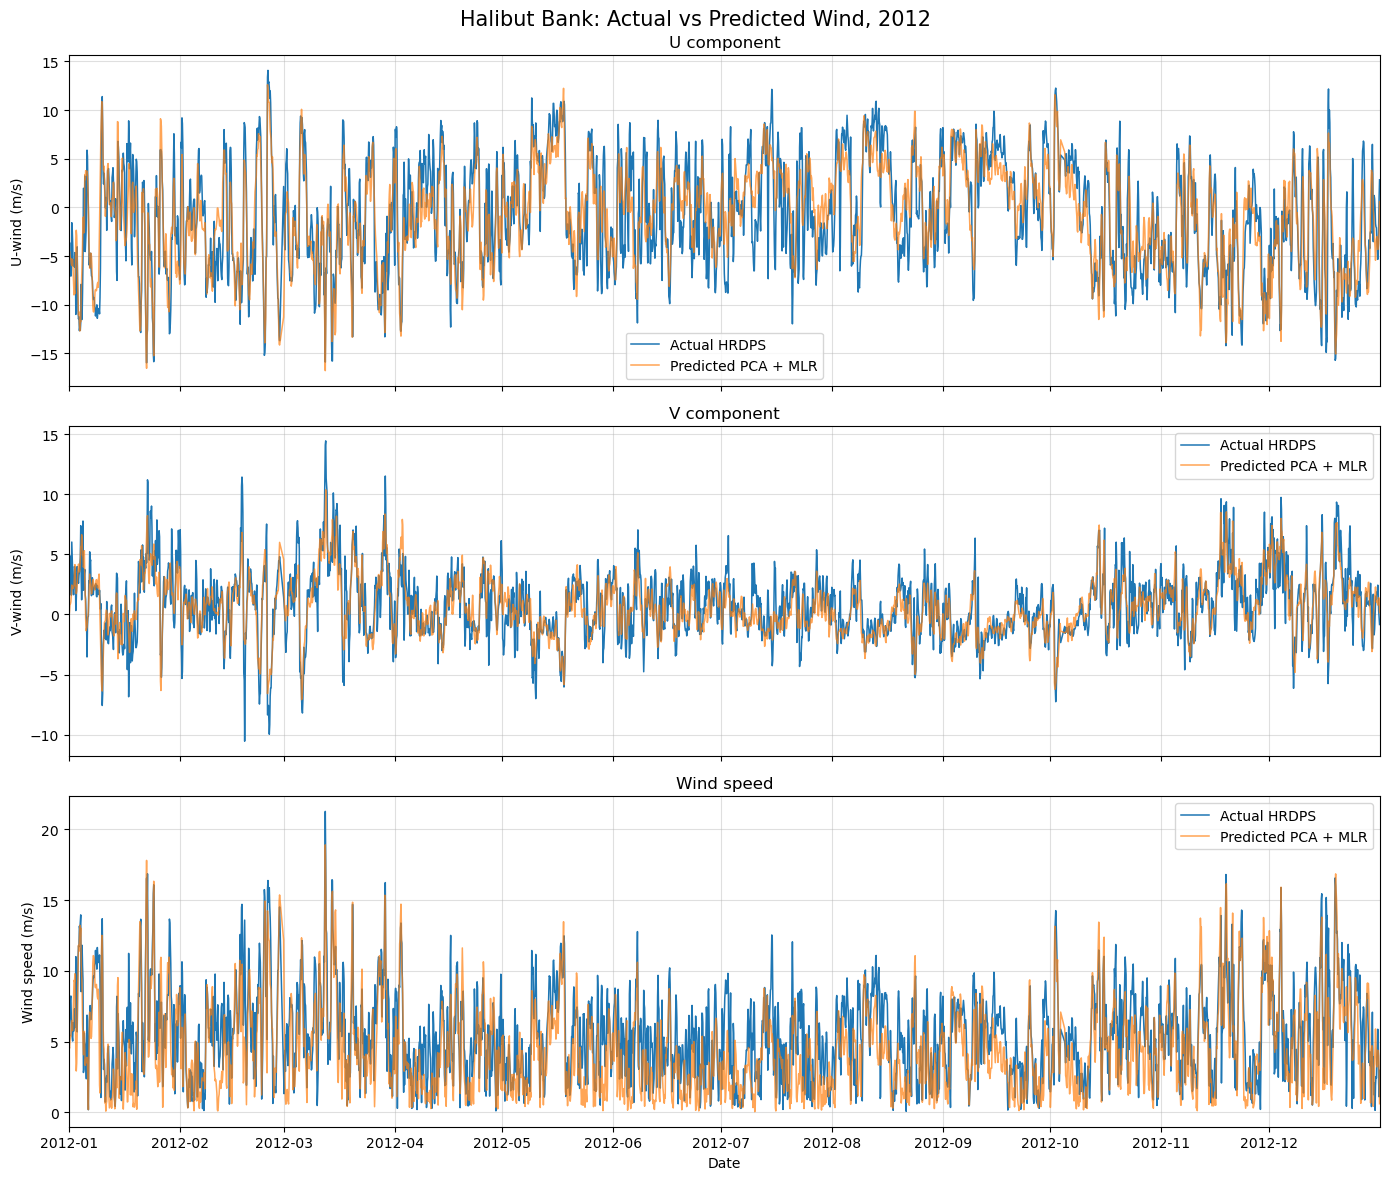

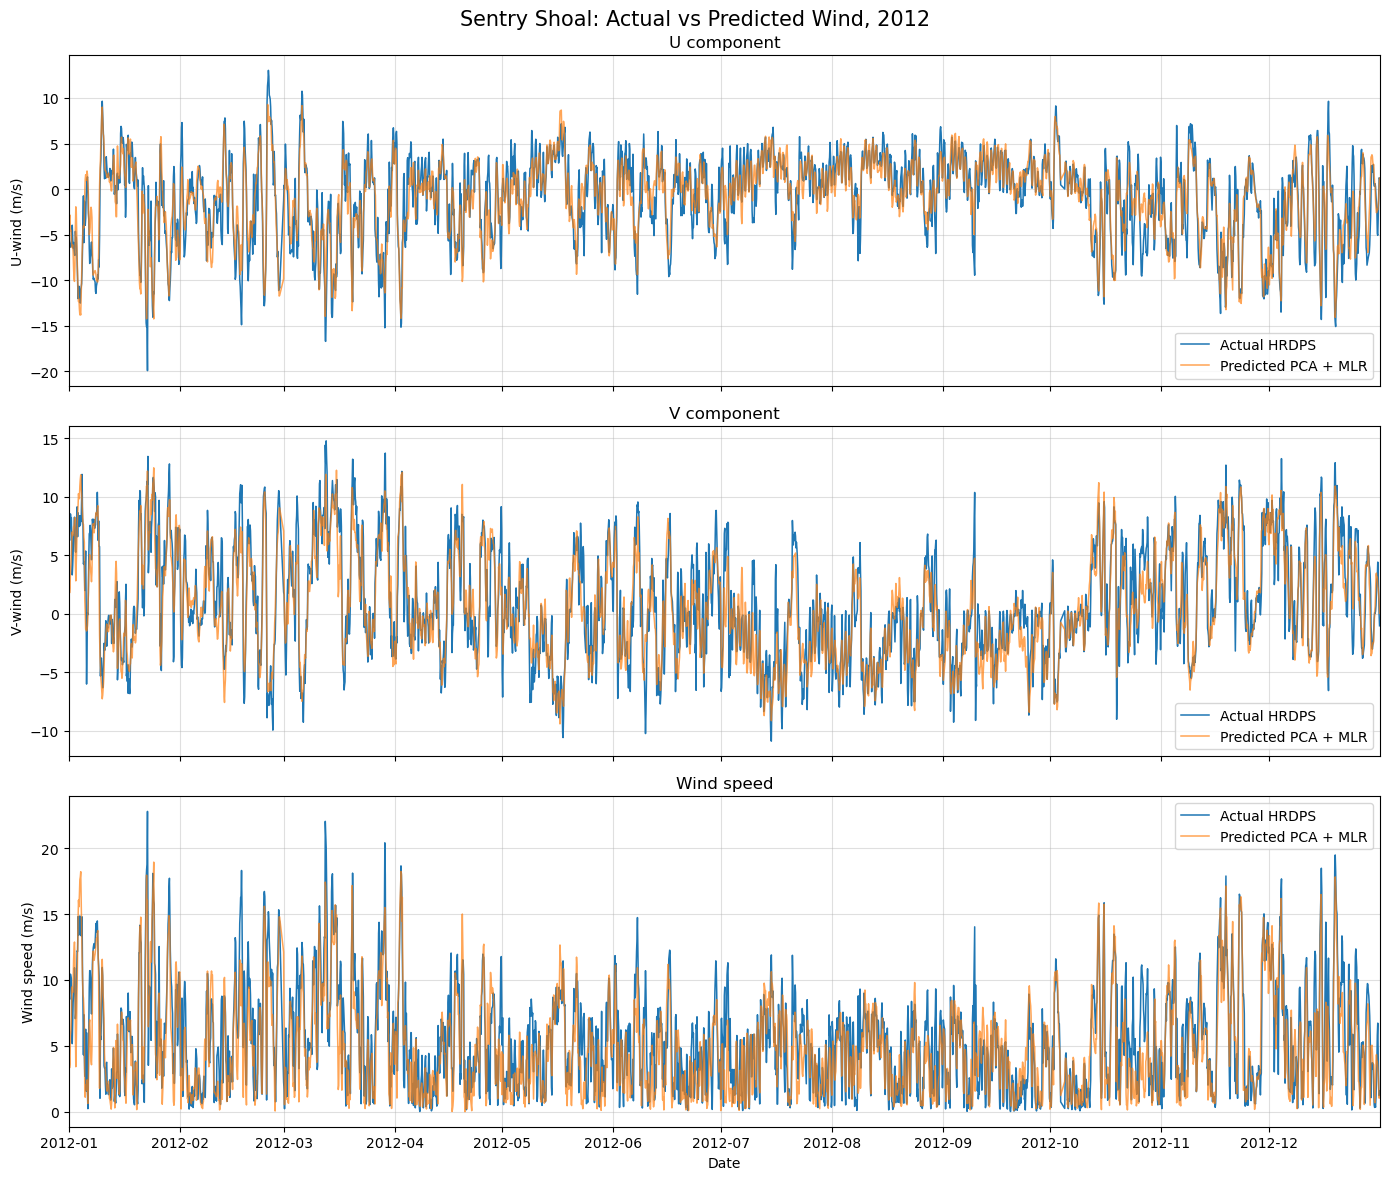

In [58]:
for station_name, station_df in station_timeseries.items():
    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    axes[0].plot(station_df.index, station_df["actual_u"], label="Actual HRDPS", linewidth=1.1)
    axes[0].plot(station_df.index, station_df["predicted_u"], label="Predicted PCA + MLR", linewidth=1.1, alpha=0.7)
    axes[0].set_ylabel("U-wind (m/s)")
    axes[0].set_title("U component")
    axes[0].legend()
    axes[0].grid(True, alpha=0.4)
    axes[1].plot(station_df.index, station_df["actual_v"], label="Actual HRDPS", linewidth=1.1)
    axes[1].plot(station_df.index, station_df["predicted_v"], label="Predicted PCA + MLR", linewidth=1.1, alpha=0.7)
    axes[1].set_ylabel("V-wind (m/s)")
    axes[1].set_title("V component")
    axes[1].legend()
    axes[1].grid(True, alpha=0.4)
    axes[2].plot(station_df.index, station_df["actual_speed"], label="Actual HRDPS", linewidth=1.1)
    axes[2].plot(station_df.index, station_df["predicted_speed"], label="Predicted PCA + MLR", linewidth=1.1, alpha=0.7)
    axes[2].set_ylabel("Wind speed (m/s)")
    axes[2].set_xlabel("Date")
    axes[2].set_title("Wind speed")
    axes[2].legend()
    axes[2].grid(True, alpha=0.4)
    axes[2].set_xlim(pd.Timestamp("2012-01-01"), pd.Timestamp("2012-12-31 23:59:59"))
    fig.suptitle(f"{station_name}: Actual vs Predicted Wind, 2012", fontsize=15)
    plt.tight_layout()
    plt.show()

In [59]:
average_station_metrics = station_rmse_table[["RMSE_u_mps", "RMSE_v_mps", "RMSE_speed_mps", "Vector_RMSE_mps"]].mean()
print("Average station metrics:")
print(average_station_metrics)

Average station metrics:
RMSE_u_mps         2.592294
RMSE_v_mps         1.930326
RMSE_speed_mps     2.393799
Vector_RMSE_mps    3.256100
dtype: float64


In [60]:
metrics_output_dir = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/results/wind_pca_mlr"
os.makedirs(metrics_output_dir, exist_ok=True)
summary_metrics = pd.DataFrame([
    {"split": "validation", "variable": "u", **val_u_metrics},
    {"split": "validation", "variable": "v", **val_v_metrics},
    {"split": "validation", "variable": "speed", **val_speed_metrics},
    {"split": "test", "variable": "u", **test_u_metrics},
    {"split": "test", "variable": "v", **test_v_metrics},
    {"split": "test", "variable": "speed", **test_speed_metrics},
])
summary_metrics["selected_hrdps_pcs"] = n_hrdps_pcs
summary_metrics["selected_canrcm_pcs"] = n_canrcm_pcs
summary_metrics["pc_space_test_r2"] = test_pc_r2
summary_metrics.to_csv(f"{metrics_output_dir}/wind_summary_metrics.csv", index=False)
station_rmse_table.to_csv(f"{metrics_output_dir}/wind_station_metrics.csv", index=False)
print(summary_metrics)
print("Saved metrics to:", metrics_output_dir)

        split variable      RMSE       MAE      Bias        R2  \
0  validation        u  2.155313  1.531434  0.003076  0.698330   
1  validation        v  1.712994  1.247604  0.030670  0.676501   
2  validation    speed  2.008046  1.466246 -0.591969  0.463500   
3        test        u  2.140568  1.564742  0.052264  0.717114   
4        test        v  1.771111  1.326717 -0.200976  0.694540   
5        test    speed  2.052426  1.537296 -0.724100  0.501604   

   selected_hrdps_pcs  selected_canrcm_pcs  pc_space_test_r2  
0                  65                  100          0.727645  
1                  65                  100          0.727645  
2                  65                  100          0.727645  
3                  65                  100          0.727645  
4                  65                  100          0.727645  
5                  65                  100          0.727645  
Saved metrics to: /ocean/dtaneja/MOAD/analysis-dishika/notebooks/results/wind_pca_mlr
